# Automated Detection and Grading of Diabetic Retinopathy using Deep Learning
- **Objective**: Train and evaluate deep-learning models in classification of diabetic retinopathy grades
- **Reference**:
  - Decencière et al.. Feedback on a publicly distributed database: the Messidor database.Image Analysis & Stereology, v. 33, n. 3, p. 231-234, aug. 2014. ISSN 1854-5165.Available at: http://www.ias-iss.org/ojs/IAS/article/view/1155 or http://dx.doi.org/10.5566/ias.1155.

In [ ]:
# Import basic modules
import re
import os
import glob
import torch
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

# Install supporting libraries
!pip -q install torchvista torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.8 MB/s eta 0:00:00


## Data and preprocessing
- This project uses the Messidor retinal fundus dataset.
- Raw medical images are not included in this repository. Obtain the dataset from its official source and place the extracted files under `messidor_dataset/`.

In [ ]:
# Dataset setup
# Download the Messidor dataset from its official source, then place the files in:
#   messidor_dataset/
# The original private Google Drive link has been removed from the public version.


In [ ]:
import shutil
import zipfile
from pathlib import Path

# Path to dataset folder
dataset_path = Path('messidor_dataset')

# Loop over all zip files
for zip_path in dataset_path.glob('*.zip'):
    folder = dataset_path / zip_path.stem   # Folder = zip file name without .zip
    folder.mkdir(exist_ok=True)             # Create folder
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(folder)          # Extract into folder
    zip_path.unlink()                       # Delete the zip file

# List of folders that have nested folders
nested_folders = ['messidor_dataset/Base11', 'messidor_dataset/Base13']

for outer in nested_folders:
    outer_path = Path(outer)

    # Get the inner folder (should be only one)
    inner_folders = [f for f in outer_path.iterdir() if f.is_dir()]

    if len(inner_folders) == 1:
        inner_path = inner_folders[0]

        # Move all files from inner folder to outer folder
        for file in inner_path.iterdir():
            shutil.move(str(file), outer_path)

        # Remove the now-empty inner folder
        inner_path.rmdir()
        print(f"Moved files from {inner_path} to {outer_path} and removed inner folder.")
    else:
        print(f"Skipping {outer_path}: found {len(inner_folders)} inner folders")


Moved files from messidor_dataset/Base11/Base11 to messidor_dataset/Base11 and removed inner folder.
Moved files from messidor_dataset/Base13/Base13 to messidor_dataset/Base13 and removed inner folder.


In [ ]:
# Pre-define seeds
def set_seed(seed=25):
  random.seed(SEED)
  np.random.seed(SEED)
  torch.manual_seed(SEED)
  torch.cuda.manual_seed_all(seed)

SEED = 25
set_seed(SEED)


In [ ]:
# Create directory to store results - later to be zipped and downloaded
os.makedirs("/content/model_res/train_validation", exist_ok=True)
os.makedirs("/content/model_res/test", exist_ok=True)
os.makedirs("/content/model_res/checkpoint_files", exist_ok=True)

### Label annotations and train-validation-test split

In [ ]:
# Extract load the .xls files containing information of image filename and the corresponding labelled retinopathy grades
annot_files = glob.glob(f"/content/messidor_dataset/*/*.xls")

# Merge all annotations into a single dataframe and include the sub-directory name as a column (i.e. "Base*")
annotations = []

for f in annot_files:
  annot_df = pd.read_excel(f)
  basename = os.path.basename(f)
  annot_df['SUB_DIR'] = re.split(r'[_. ]', basename)[1]
  annotations.append(annot_df)

annotations = pd.concat(annotations)
annotations.columns = ['IMAGE_NAME', 'SOURCE', 'RETINOPATHY_GRADE', 'MACULAR_EDEMA_RISK', 'SUB_DIR']
annotations.head(3)


,IMAGE_NAME,SOURCE,RETINOPATHY_GRADE,MACULAR_EDEMA_RISK,SUB_DIR
0,20060412_52446_0200_PP.tif,CHU de St Etienne,0,0,Base24
1,20060412_52497_0200_PP.tif,CHU de St Etienne,3,0,Base24
2,20060412_52520_0200_PP.tif,CHU de St Etienne,3,0,Base24


In [ ]:
# Create binary labels ("BINARY_GRADE") - RETINOPATHY_GRADE 1_2 versus RETINOPATHY_GRADE 3_4
# Objective: Classification of "Non-Refereable" and "Referable" groups - ["No DR", "Mild DR"] versus ["Moderate DR", "Severe DR"]
# This aims at assisting clinical decisions whether patients need to be referred for further examination like anti-VEGF therapy

annotations['BINARY_GRADE'] = annotations['RETINOPATHY_GRADE'].apply(lambda x: 1 if x > 1 else 0)
annotations.head(3)

,IMAGE_NAME,SOURCE,RETINOPATHY_GRADE,MACULAR_EDEMA_RISK,SUB_DIR,BINARY_GRADE
0,20060412_52446_0200_PP.tif,CHU de St Etienne,0,0,Base24,0
1,20060412_52497_0200_PP.tif,CHU de St Etienne,3,0,Base24,1
2,20060412_52520_0200_PP.tif,CHU de St Etienne,3,0,Base24,1


In [ ]:
from sklearn.model_selection import train_test_split

SEED = 25 # Main seed to used throughout analysis
MAIN_LABEL = 'BINARY_GRADE' # Main label column to use

# Split data into train, validation, test - 80/20/20 and stratify by label
train_df, val_test_df = train_test_split(annotations, test_size=0.2, random_state=SEED, stratify=annotations[MAIN_LABEL])

val_df, test_df = train_test_split(val_test_df, test_size=0.5, random_state=SEED, stratify=val_test_df[MAIN_LABEL])

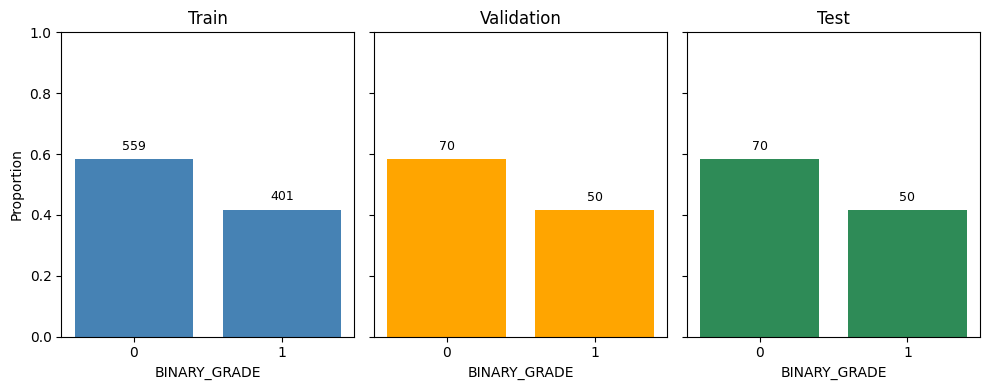

In [ ]:
# Plot to check visualize distribution of 'RETINOPATHY_GRADE' across sets
train_props = train_df[MAIN_LABEL].value_counts(normalize=True).sort_index()
val_props   = val_df[MAIN_LABEL].value_counts(normalize=True).sort_index()
test_props  = test_df[MAIN_LABEL].value_counts(normalize=True).sort_index()

train_counts = train_df[MAIN_LABEL].value_counts().sort_index()
val_counts   = val_df[MAIN_LABEL].value_counts().sort_index()
test_counts  = test_df[MAIN_LABEL].value_counts().sort_index()

# Labels
labels = train_props.index.astype(str).tolist()

# Create figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

# Combine all data for easy looping
datasets = [
    ("Train", train_props, train_counts, "steelblue"),
    ("Validation", val_props, val_counts, "orange"),
    ("Test", test_props, test_counts, "seagreen"),
]

# Plot
for ax, (title, prop_data, count_data, color) in zip(axes, datasets):
    bars = ax.bar(labels, prop_data, color=color)
    ax.set_title(title)
    ax.set_xlabel(MAIN_LABEL)
    ax.set_ylim(0, 1)

    # Add count labels on top of each bar
    for bar, count in zip(bars, count_data):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,              # position slightly above the bar
            f"{count}",                 # show raw count
            ha="center",
            va="bottom",
            fontsize=9
        )

# Common Y label
axes[0].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

### Creating `CustomImageDataset` and `DataLoaders` with transformations

In [ ]:
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class CustomImageDataset(Dataset):
  def __init__(self, df, transform=None):
    self.df = df
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    img_name = self.df.iloc[idx]['IMAGE_NAME']
    img_sub_dir = self.df.iloc[idx]['SUB_DIR']
    img_path = f"/content/messidor_dataset/{img_sub_dir}/{img_name}"
    image = Image.open(img_path).convert('RGB')
    label = torch.tensor(self.df.iloc[idx][MAIN_LABEL], dtype=torch.long)

    if self.transform:
      image = self.transform(image)

    return image, label

In [ ]:
# Imbalanced training set - perform undersampling of majority class
minority_class_size = train_df[MAIN_LABEL].value_counts().min() # Class:1

majority_class = train_df[train_df[MAIN_LABEL] == 0].sample(n=minority_class_size, random_state=SEED)

train_df = pd.concat([majority_class, train_df[train_df[MAIN_LABEL] == 1]])

print("New distribution of training set after undersampling:")
print(train_df[MAIN_LABEL].value_counts())

New distribution of training set after undersampling:
BINARY_GRADE
0    401
1    401
Name: count, dtype: int64


In [ ]:
# Calculate `mean` and `std` for the channels in training set
# Here, for our training set, we wish to perform a resize followed by a CenterCrop

# Most CNN architectures (including pretrained) expects inputs size of 224x224 by convention
TARGET_SIZE = 224

# Resize "shorter side" of each image to 256 pixels before taking 224x224 center crop
# Handle images with different aspect ratios
RESIZE_SIZE = int(TARGET_SIZE * (256 / 224))

# Define transformations
transform_stats = transforms.Compose([
    transforms.Resize(RESIZE_SIZE),
    transforms.CenterCrop(TARGET_SIZE),
    transforms.ToTensor()
])

# Compute mean and std
train_dataset = CustomImageDataset(train_df, transform=transform_stats)
loader = DataLoader(train_dataset, batch_size=64, shuffle=False)

mean = 0.
std = 0.
n_images = 0

for images, _ in loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    n_images += batch_samples

TRAIN_MEAN = mean / n_images
TRAIN_STD = std / n_images

print("TRAIN_MEAN: ", TRAIN_MEAN)
print("TRAIN_STD: ", TRAIN_STD)


TRAIN_MEAN:  tensor([0.5773, 0.2716, 0.0884])
TRAIN_STD:  tensor([0.2405, 0.1207, 0.0464])


In [ ]:
# Set-up actual transformations with normalization

# Transformations for training set with RandomHorizontalFlip augmentation
transform_train = transforms.Compose([
    transforms.Resize(RESIZE_SIZE),
    transforms.CenterCrop(TARGET_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD)
])

# Transformations for validation and test sets
transform_valtest = transforms.Compose([
    transforms.Resize(RESIZE_SIZE),
    transforms.CenterCrop(TARGET_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD)
])

# Load the training, validation, and test sets with defined transformation
train_ds = CustomImageDataset(train_df, transform=transform_train)
val_ds   = CustomImageDataset(val_df,   transform=transform_valtest)
test_ds  = CustomImageDataset(test_df,  transform=transform_valtest)


In [ ]:
# Compute class weights
class_counts = train_df[MAIN_LABEL].value_counts().sort_index()
num_samples = sum(class_counts)
class_weights = [num_samples / (len(class_counts) * count) for count in class_counts]

class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)

tensor([1., 1.])


In [ ]:
# Setting DataLoader
BATCH_SIZE = 32

# Prepare PyTorch DataLoader objects for batch processing
# Shuffle the training data for better training performance
# Apparently multiprocessing (num_workers > 0) introduces randomness, set num_workers=0
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

#### Image inspection

In [ ]:
# Helper function to convert tensors to RGB
def tensor_to_rgb(img, mean, std):
  img2show = img.clone().cpu()

  # Reverse normalization (if needed)
  mu = torch.as_tensor(mean).reshape(3, 1, 1)
  sigma = torch.as_tensor(std).reshape(3, 1, 1)
  img2show = img2show * sigma + mu
  img2show = img2show.clamp(0,1)

  # Reorder channels for matplotlib
  img2show = np.transpose(img2show.numpy(), (1,2,0)) # [C,H,W] -> [H,W,C]

  return(img2show)

# Function to plot image ()
def plot_image(img, lbl, pred_class = None, mean = TRAIN_MEAN, std = TRAIN_STD):

    img2show = tensor_to_rgb(img, mean, std) # Get RGB image

    label = lbl.item() # Get label value

    # Build title for ground truth label
    title = f"True label: {label}"

    # Add prediction label if specified
    if pred_class is not None:
        title += f"\nPredicted label: {pred_class}"

    # Plot
    plt.imshow(img2show)
    plt.title(title)
    plt.axis("off")
    plt.show()

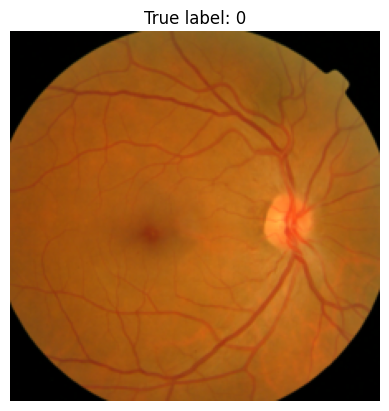

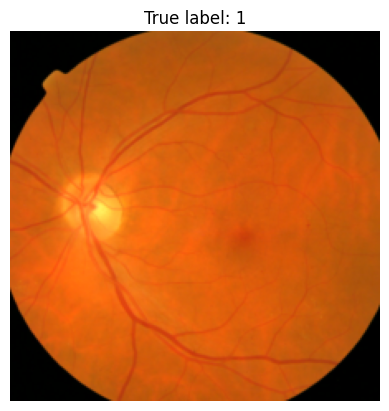

In [ ]:
# View a random pair of Label 0 and Label 1 images
images, labels = next(iter(train_loader))
labels_toview = [0, 1]

while not all(l in labels for l in labels_toview):
  images, labels = next(iter(train_loader))

# Fetch first indices of each label
first_indices = []
for l in labels_toview:
  matches = (labels == l).nonzero(as_tuple=True)[0]
  if len(matches) > 0:
    first_indices.append(matches[0].item())

# Visual comparison between images with different grades
for idx in first_indices:
  plot_image(images[idx], labels[idx])

In [ ]:
# Check shape of images and labels
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


## Training and Evaluation
Here, we will be trying out a variety of models, starting with a simple CNN architecture, followed by exploring pretrained models (e.g., ResNet, EfficientNet, DenseNet).

For pretrained models, we would also evaluate performances between training from scratch, or fine-tuning on pre-trained weights or transfer-learning.

#### Training and evaluation functions
Some functions and reduce the amount of repeated code required for each training and evaluation.

In [ ]:
# ---- Training and validation epochs ----
def train_one_epoch(model, loader, criterion, optimizer, metric, device):
  model.train()
  total_loss = 0.0
  metric.reset()

  for xb, yb in tqdm(loader, desc="Training", leave=False):
    xb, yb = xb.to(device), yb.squeeze().to(device)
    optimizer.zero_grad()
    output = model(xb)
    loss = criterion(output, yb)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    metric.update(output, yb)

  avg_loss = total_loss / max(1, len(loader))
  avg_metric = metric.compute().item()

  return avg_loss, avg_metric

def validate_one_epoch(model, loader, criterion, metric, device):
  model.eval()
  total_loss = 0.0
  metric.reset()

  with torch.no_grad():
    for xb, yb in tqdm(loader, desc="Validation", leave=False):
      xb, yb = xb.to(device), yb.squeeze().to(device)
      output = model(xb)
      loss = criterion(output, yb)

      total_loss += loss.item()
      metric.update(output, yb)

  avg_loss = total_loss / max(1, len(loader))
  avg_metric = metric.compute().item()

  return avg_loss, avg_metric

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                train_metric, val_metric, num_epochs, device, patience, min_delta,
                checkpoint_file, report_interval=1):
    """
    Train a model with validation, early stopping, and checkpointing.

    Args:
        model: PyTorch model
        train_loader: Training data loader
        val_loader: Validation data loader
        criterion: Loss function
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        train_metric: Training metric function
        val_metric: Validation metric function
        num_epochs: Number of epochs
        device: Device (cpu/cuda)
        patience: Early stopping patience
        min_delta: Minimum change to qualify as improvement
        checkpoint_file: Path to save checkpoints
        report_interval: Reporting frequency (default 1)

    Returns:
        Dictionary containing:
            - train_losses: List of training losses per epoch
            - train_metrics: List of training metrics per epoch
            - val_losses: List of validation losses per epoch
            - val_metrics: List of validation metrics per epoch
            - best_epoch: Epoch with best validation loss
            - best_val_loss: Best validation loss achieved
    """
    best_val_loss = float("inf")
    no_improve_count = 0

    running_train_loss, running_train_metric = [], []
    running_val_loss, running_val_metric = [], []

    for epoch in range(num_epochs):
        avg_train_loss, avg_train_metric = train_one_epoch(
            model, train_loader, criterion, optimizer, train_metric, device
        )
        avg_val_loss, avg_val_metric = validate_one_epoch(
            model, val_loader, criterion, val_metric, device
        )

        # Track metrics
        running_train_loss.append(avg_train_loss)
        running_train_metric.append(avg_train_metric)
        running_val_loss.append(avg_val_loss)
        running_val_metric.append(avg_val_metric)

        # Scheduler step
        scheduler.step(avg_val_loss)

        # Checkpointing + Early Stopping
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            no_improve_count = 0
            torch.save({
                "epoch": epoch,
                "best_val_loss": best_val_loss,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
            }, checkpoint_file)
            print(f"Epoch {epoch+1}: Saved new best model (val_loss={best_val_loss:.4f})")
        else:
            no_improve_count += 1
            print(f"Epoch {epoch+1}: No improvement ({no_improve_count}/{patience})")
            if no_improve_count >= patience:
                print(f"Epoch {epoch+1}: Early stopping triggered.")
                break

        # Reporting
        if (epoch + 1) % report_interval == 0 or (epoch + 1) == 1 or (epoch + 1) == num_epochs:
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Train loss: {avg_train_loss:.4f}, F1: {avg_train_metric:.3f} | "
                f"Val loss: {avg_val_loss:.4f}, F1: {avg_val_metric:.3f}"
            )

    return {
        "train_losses": running_train_loss,
        "train_metrics": running_train_metric,
        "val_losses": running_val_loss,
        "val_metrics": running_val_metric,
        "best_epoch": len(running_train_loss) - no_improve_count - 1,
        "best_val_loss": best_val_loss,
    }

In [ ]:
# Visualization of loss curves
def loss_curves(running_train_loss, running_val_loss,
                running_train_metric, running_val_metric,
                metric='Accuracy', best_epoch=None):
    """
    Plot training and validation loss/metric curves.

    Args:
        running_train_loss: List of training losses per epoch
        running_val_loss: List of validation losses per epoch
        running_train_metric: List of training metrics per epoch
        running_val_metric: List of validation metrics per epoch
        metric: Name of the metric (default: 'Accuracy')
        best_epoch: Index of best epoch (0-indexed). If provided, highlights this epoch
    """

    # Create 1-indexed epoch numbers
    epochs = range(1, len(running_train_loss) + 1)

    # Loss curves
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, running_train_loss, label='Train Loss', marker='o', markersize=4)
    plt.plot(epochs, running_val_loss, label='Validation Loss', marker='s', markersize=4)

    # Highlight best epoch if provided
    if best_epoch is not None:
        best_epoch_1indexed = best_epoch + 1
        best_val_loss = running_val_loss[best_epoch]
        plt.axvline(x=best_epoch_1indexed, color='red', linestyle='--',
                    alpha=0.7, label=f'Best Epoch ({best_epoch_1indexed})')
        plt.scatter([best_epoch_1indexed], [best_val_loss], color='red', s=100, zorder=5)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss Curves')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(epochs)
    plt.show()

    # Metric curves
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, running_train_metric, label='Train Metric', marker='o', markersize=4)
    plt.plot(epochs, running_val_metric, label='Validation Metric', marker='s', markersize=4)

    # Highlight best epoch if provided
    if best_epoch is not None:
        best_epoch_1indexed = best_epoch + 1
        best_val_metric = running_val_metric[best_epoch]
        plt.axvline(x=best_epoch_1indexed, color='red', linestyle='--',
                    alpha=0.7, label=f'Best Epoch ({best_epoch_1indexed})')
        plt.scatter([best_epoch_1indexed], [best_val_metric], color='red', s=100, zorder=5)

    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.title('Training & Validation Metric Curves')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(epochs)
    plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report, precision_recall_fscore_support

# Test Evaluation
def evaluate_model(model, test_loader, criterion, test_metric,
    checkpoint_file=None, device=None, class_names=None,
    show_confusion_matrix=True, show_classification_report=True,
    figsize=(10, 8)):
    """
    Comprehensive test evaluation function for PyTorch models.

    Args:
        model: PyTorch model to evaluate
        test_loader: DataLoader for test set
        criterion: Loss function
        test_metric: TorchMetrics metric object (e.g., Accuracy)
        checkpoint_file: Path to checkpoint file (if None, uses current model state)
        device: Device to run evaluation on (if None, auto-detects)
        class_names: List of class names for better visualization (optional)
        show_confusion_matrix: Whether to plot confusion matrix
        show_classification_report: Whether to print classification report
        figsize: Figure size for confusion matrix plot

    Returns:
        dict: Dictionary containing:
            - 'test_loss': Average test loss
            - 'test_accuracy': Test accuracy (or other metric value)
            - 'predictions': List of predicted labels
            - 'labels': List of true labels
            - 'confusion_matrix': Confusion matrix array
    """

    # Auto-detect device if not provided
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load checkpoint if provided
    if checkpoint_file is not None:
        print(f"Loading model from {checkpoint_file}...")
        checkpoint = torch.load(checkpoint_file, map_location=device)
        model.load_state_dict(checkpoint["model_state"])
        if "best_val_loss" in checkpoint:
            print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")
        if "epoch" in checkpoint:
            print(f"Checkpoint from epoch: {checkpoint['epoch'] + 1}")

    # Ensure metric is on correct device
    test_metric = test_metric.to(device)

    # Initialize tracking variables
    test_loss_sum = 0.0
    test_metric.reset()
    all_preds = []
    all_labels = []

    # Evaluate on test set
    model.eval()
    print("\nEvaluating on test set...")

    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc="Testing"):
            xb, yb = xb.to(device), yb.view(-1).to(device)

            # Forward pass
            output = model(xb)
            loss = criterion(output, yb)

            # Get predictions
            preds = output.argmax(dim=1)

            # Update metrics
            test_loss_sum += loss.item()
            test_metric.update(output, yb)

            # Collect labels and predictions
            all_labels.extend(yb.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # Calculate final metrics
    avg_test_loss = test_loss_sum / len(test_loader)
    test_metric_value = test_metric.compute().item()

    # Print results
    print("\n" + "="*60)
    print("TEST RESULTS")
    print("="*60)
    print(f"Test Loss:   {avg_test_loss:.4f}")
    print(f"Test Metric: {test_metric_value:.4f} ({test_metric_value*100:.2f}%)")
    print(f"Total Samples: {len(all_labels)}")
    print("="*60)

    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Infer number of classes from confusion matrix
    num_classes = cm.shape[0]

    # Classification report
    if show_classification_report:
        print("\nCLASSIFICATION REPORT")
        print("="*60)
        if class_names is not None:
            target_names = class_names
        else:
            target_names = [f"Class {i}" for i in range(num_classes)]

        print(classification_report(
            all_labels,
            all_preds,
            target_names=target_names,
            digits=4
        ))

    # Plot confusion matrix
    if show_confusion_matrix:
        plt.figure(figsize=figsize)

        if class_names is not None:
            disp = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=class_names
            )
        else:
            disp = ConfusionMatrixDisplay(confusion_matrix=cm)

        disp.plot(cmap="Blues", values_format='d')
        plt.title(f"Confusion Matrix (Metric: {test_metric_value:.2%})", fontsize=14, pad=20)
        plt.xlabel("Predicted Label", fontsize=12)
        plt.ylabel("True Label", fontsize=12)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    # Calculate per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average=None
    )

    print("\nPER-CLASS METRICS")
    print("="*60)
    for i in range(num_classes):
        class_name = class_names[i] if class_names else f"Class {i}"
        print(f"{class_name:15s} | "
              f"Precision: {precision[i]:.4f} | "
              f"Recall: {recall[i]:.4f} | "
              f"F1: {f1[i]:.4f} | "
              f"Support: {support[i]:4d}")

    # Return results
    results = {
        'test_loss': avg_test_loss,
        'test_metric': test_metric_value,
        'predictions': all_preds,
        'labels': all_labels,
        'confusion_matrix': cm,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'support': support
    }

    return results

##### Device settings

In [ ]:
# Defining basic parameters
# Select device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

# ---- Training Configurations ----
REPORT_INTERVAL = 5 # print losses every 5 epochs
PATIENCE = 10
MIN_DELTA = 1e-4 # minimum change to qualify as improvement

# ---- Store results in dictionary ----
eval_results = {}

cuda


## Simple CNN architecture

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# Setup SimpleCNN class

class SimpleCNN(nn.Module):
  def __init__(self, num_classes, input_size=224):
    super(SimpleCNN, self).__init__()

    self.input_size = input_size

    # Convolutional layers
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
    self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
    self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)

    # Max pooling layer
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    # Calculate size after convolutions and pooling
    # Each pooling layer dvides dimensions by 2
    self.feature_size = input_size // (2 ** 3) # 3 pooling layers
    self.flattened_size = 128 * self.feature_size * self.feature_size

    # Fully connected layers
    self.fc1 = nn.Linear(in_features=self.flattened_size, out_features=256) # after 3 pooling layers, 224 -> 112 -> 56 -> 28
    self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    # Dropout for regularization
    self.dropout = nn.Dropout(p=0.5)

  def forward(self, x):
    # Convolutional layers
    x = self.pool(F.relu(self.conv1(x))) # 224 -> 112
    x = self.pool(F.relu(self.conv2(x))) # 112 -> 56
    x = self.pool(F.relu(self.conv3(x))) # 56 -> 28

    # Flatten for fully connected layers
    x = x.view(x.size(0), -1)

    # Full connected layers
    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.fc2(x)

    return x

In [ ]:
# Instantiate model
NUM_CLASSES = len(train_df[MAIN_LABEL].unique())
INPUT_SIZE = TARGET_SIZE
model = SimpleCNN(num_classes=NUM_CLASSES, input_size=INPUT_SIZE)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
# Hyperparameters
LEARNING_RATE = 1e-3
NUM_EPOCHS = 100

# Paths
MODEL_TYPE = 'SimpleCNN'
CHECKPOINT_FILE = f"/content/model_res/checkpoint_files/checkpoint_{MODEL_TYPE}.pt"

# Move the model to GPU
model = model.to(DEVICE)

In [ ]:
from torchmetrics.classification import MulticlassF1Score
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE)) # Same criterion used throughout, not defined again later on
optimizer = torch.optim.Adam(model.parameters(),
                             lr=LEARNING_RATE,
                             weight_decay=1e-5 # Apply L2 regularization to discourage large weights (improve stability)
                             )

# Set up metrics
metric_name = 'MulticlassF1Score'
train_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
val_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# Set up scheduler
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=3) # this adjusts learning rates when there is no improvement in loss

In [ ]:
model_results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    train_metric=train_metric,
    val_metric=val_metric,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    checkpoint_file=CHECKPOINT_FILE,
    report_interval=REPORT_INTERVAL
)

# Save results as .pkl
with open(f"/content/model_res/train_validation/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(model_results, f)


Epoch 1: Saved new best model (val_loss=0.8101)
Epoch 1/100 | Train loss: 0.9552, F1: 0.586 | Val loss: 0.8101, F1: 0.562


Epoch 2: Saved new best model (val_loss=0.6646)


Epoch 3: No improvement (1/10)


Epoch 4: Saved new best model (val_loss=0.6591)


Epoch 5: No improvement (1/10)
Epoch 5/100 | Train loss: 0.6429, F1: 0.663 | Val loss: 0.6645, F1: 0.583


...

Epoch 12: No improvement (6/10)


Epoch 13: No improvement (7/10)


Epoch 14: No improvement (8/10)


Epoch 15: No improvement (9/10)
Epoch 15/100 | Train loss: 0.5808, F1: 0.697 | Val loss: 0.6462, F1: 0.591


Epoch 16: No improvement (10/10)
Epoch 16: Early stopping triggered.


#### Evaluation

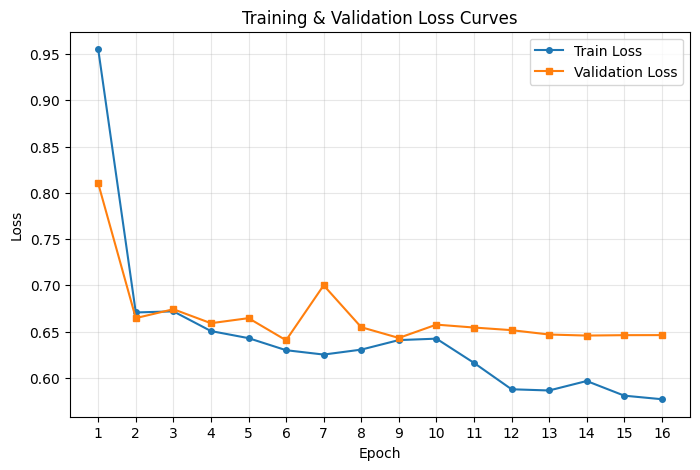

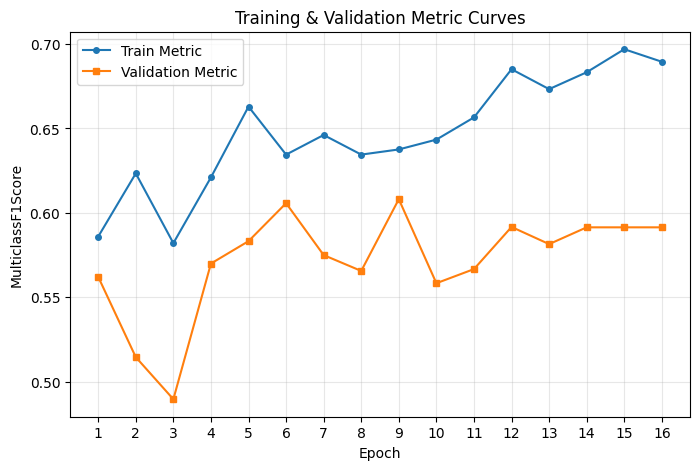

Best Epoch: 6 (Validation Loss: 0.641)


In [ ]:
# Loss and metric curves
loss_curves(model_results['train_losses'],
            model_results['val_losses'],
            model_results['train_metrics'],
            model_results['val_metrics'],
            metric = metric_name)

print(f"Best Epoch: {model_results['best_epoch']+1} (Validation Loss: {model_results['best_val_loss']:.3f})")

Loading model from /content/model_res/checkpoint_files/checkpoint_SimpleCNN.pt...
Best validation loss: 0.6406
Checkpoint from epoch: 6

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:06<00:00,  1.74s/it]


TEST RESULTS
Test Loss:   0.6350
Test Metric: 0.6050 (60.50%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.6623    0.7286    0.6939        70
     Class 1     0.5581    0.4800    0.5161        50

    accuracy                         0.6250       120
   macro avg     0.6102    0.6043    0.6050       120
weighted avg     0.6189    0.6250    0.6198       120



<Figure size 1000x800 with 0 Axes>

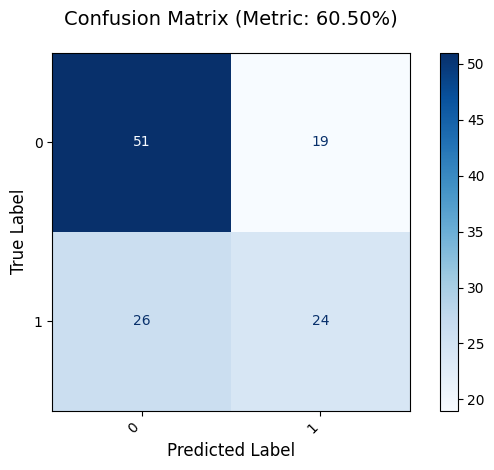


PER-CLASS METRICS
Class 0         | Precision: 0.6623 | Recall: 0.7286 | F1: 0.6939 | Support:   70
Class 1         | Precision: 0.5581 | Recall: 0.4800 | F1: 0.5161 | Support:   50


In [ ]:
# Evaluate on test set
test_metric = MulticlassF1Score(num_classes=NUM_CLASSES,
                                average="macro").to(DEVICE)

results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

# Save test evaluation results
with open(f"/content/model_res/test/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(results, f)

eval_results[MODEL_TYPE] = results

## ResNet18 architecture
- ResNet-18 is a deep convolutional neural network with 18 layers that uses residual (skip) connections to enable stable training of deeper models by mitigating vanishing gradients.

### From scratch

In [ ]:
import torchvision.models as models

# Training ResNet model from scratch
model = models.resnet18(weights=None, num_classes=NUM_CLASSES)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Paths
MODEL_TYPE = 'RESNET18'
CHECKPOINT_FILE = f"/content/model_res/checkpoint_files/checkpoint_{MODEL_TYPE}.pt"

# Reset metrics (in case it accumulated any internal states from previous training)
train_metric.reset()
val_metric.reset()

# Set up optimizer and scheduler
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(model.parameters(),
                             lr=LEARNING_RATE,
                             weight_decay=1e-5
                             )

scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=3)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
model_results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    train_metric=train_metric,
    val_metric=val_metric,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    checkpoint_file=CHECKPOINT_FILE,
    report_interval=REPORT_INTERVAL
)

# Save results as .pkl
with open(f"/content/model_res/train_validation/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(model_results, f)

Epoch 1: Saved new best model (val_loss=5.5783)
Epoch 1/100 | Train loss: 0.8845, F1: 0.565 | Val loss: 5.5783, F1: 0.489


Epoch 2: Saved new best model (val_loss=0.6671)


Epoch 3: No improvement (1/10)


Epoch 4: No improvement (2/10)


Epoch 5: No improvement (3/10)
Epoch 5/100 | Train loss: 0.6651, F1: 0.610 | Val loss: 0.6944, F1: 0.574


...

Epoch 8: No improvement (6/10)


Epoch 9: No improvement (7/10)


Epoch 10: No improvement (8/10)
Epoch 10/100 | Train loss: 0.6486, F1: 0.631 | Val loss: 0.6853, F1: 0.565


Epoch 11: No improvement (9/10)


Epoch 12: No improvement (10/10)
Epoch 12: Early stopping triggered.


#### Evaluation

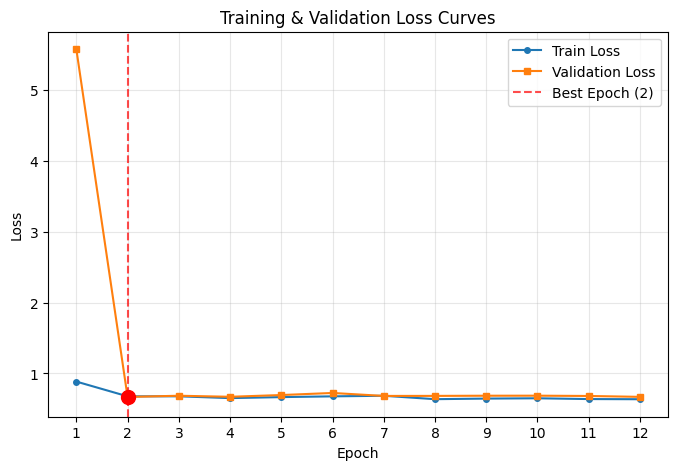

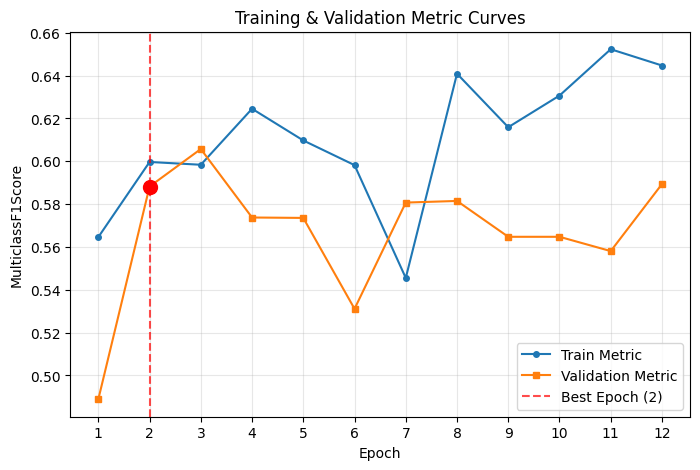

Best Epoch: 2 (Validation Loss:  0.6671354621648788 )


In [ ]:
# Loss and metric curves
loss_curves(model_results['train_losses'],
            model_results['val_losses'],
            model_results['train_metrics'],
            model_results['val_metrics'],
            best_epoch=model_results['best_epoch'],
            metric = metric_name)

print("Best Epoch:", model_results['best_epoch'] + 1,
      "(Validation Loss: ", model_results['best_val_loss'], ")")

Loading model from /content/model_res/checkpoint_files/checkpoint_RESNET18.pt...
Best validation loss: 0.6671
Checkpoint from epoch: 2

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:06<00:00,  1.72s/it]


TEST RESULTS
Test Loss:   0.6729
Test Metric: 0.6050 (60.50%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.6885    0.6000    0.6412        70
     Class 1     0.5254    0.6200    0.5688        50

    accuracy                         0.6083       120
   macro avg     0.6070    0.6100    0.6050       120
weighted avg     0.6206    0.6083    0.6110       120



<Figure size 1000x800 with 0 Axes>

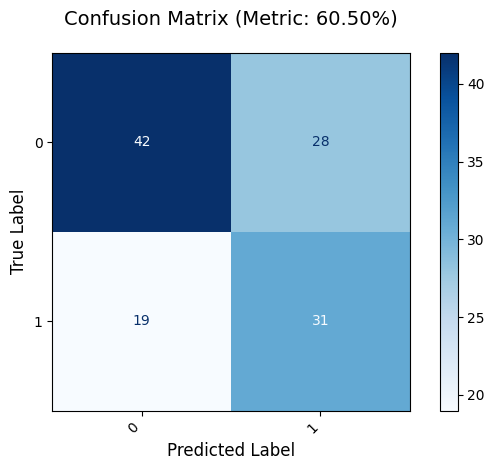


PER-CLASS METRICS
Class 0         | Precision: 0.6885 | Recall: 0.6000 | F1: 0.6412 | Support:   70
Class 1         | Precision: 0.5254 | Recall: 0.6200 | F1: 0.5688 | Support:   50


In [ ]:
# Evaluate on test set
test_metric.reset()

results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

# Save test evaluation results
with open(f"/content/model_res/test/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(results, f)

eval_results[MODEL_TYPE] = results

### Fine-tuning

In [ ]:
# Using pretrained ResNet with ImageNet weights
model = models.resnet18(weights="DEFAULT")

# Replace the final fully-connected layer to match the number of output classes for out dataset
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Paths
MODEL_TYPE = 'RESNET18_FineTuning'
CHECKPOINT_FILE = f"/content/model_res/checkpoint_files/checkpoint_{MODEL_TYPE}.pt"

# Reset metrics
train_metric.reset()
val_metric.reset()

# Set up optimizer and scheduler
LEARNING_RATE = 1e-4 # Reduced to minimize forgetting
optimizer = torch.optim.Adam(model.parameters(),
                             lr=LEARNING_RATE,
                             weight_decay=1e-5
                             )

scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=3)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
model_results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    train_metric=train_metric,
    val_metric=val_metric,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    checkpoint_file=CHECKPOINT_FILE,
    report_interval=REPORT_INTERVAL
)

# Save results as .pkl
with open(f"/content/model_res/train_validation/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(model_results, f)

Epoch 1: Saved new best model (val_loss=0.4983)
Epoch 1/100 | Train loss: 0.6070, F1: 0.705 | Val loss: 0.4983, F1: 0.715


Epoch 2: Saved new best model (val_loss=0.4765)


Epoch 3: Saved new best model (val_loss=0.4239)


Epoch 4: No improvement (1/10)


Epoch 5: No improvement (2/10)
Epoch 5/100 | Train loss: 0.1524, F1: 0.964 | Val loss: 0.4402, F1: 0.821


...

Epoch 9: No improvement (6/10)


Epoch 10: No improvement (7/10)
Epoch 10/100 | Train loss: 0.0337, F1: 0.995 | Val loss: 0.4380, F1: 0.838


Epoch 11: No improvement (8/10)


Epoch 12: No improvement (9/10)


Epoch 13: No improvement (10/10)
Epoch 13: Early stopping triggered.


#### Evaluation

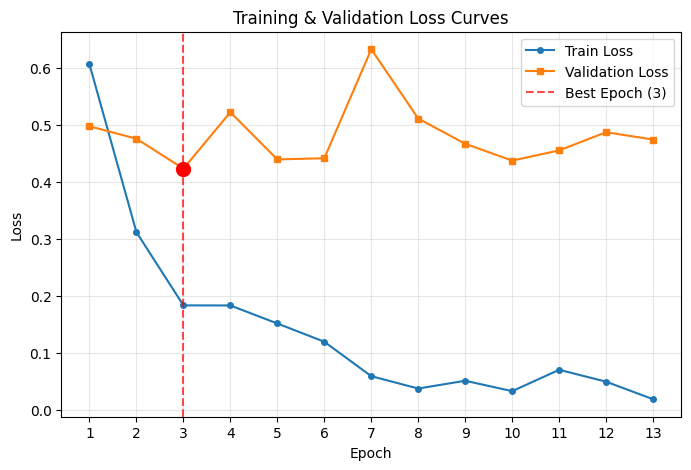

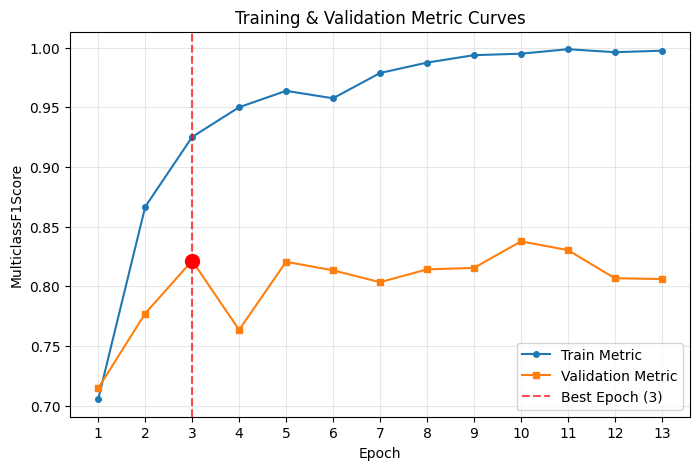

Best Epoch: 3 (Validation Loss:  0.42394254356622696 )


In [ ]:
# Loss and metric curves
loss_curves(model_results['train_losses'],
            model_results['val_losses'],
            model_results['train_metrics'],
            model_results['val_metrics'],
            best_epoch=model_results['best_epoch'],
            metric = metric_name)

print("Best Epoch:", model_results['best_epoch'] + 1,
      "(Validation Loss: ", model_results['best_val_loss'], ")")

Loading model from /content/model_res/checkpoint_files/checkpoint_RESNET18_FineTuning.pt...
Best validation loss: 0.4239
Checkpoint from epoch: 3

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:03<00:00,  1.12it/s]


TEST RESULTS
Test Loss:   0.5220
Test Metric: 0.7692 (76.92%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.8116    0.8000    0.8058        70
     Class 1     0.7255    0.7400    0.7327        50

    accuracy                         0.7750       120
   macro avg     0.7685    0.7700    0.7692       120
weighted avg     0.7757    0.7750    0.7753       120



<Figure size 1000x800 with 0 Axes>

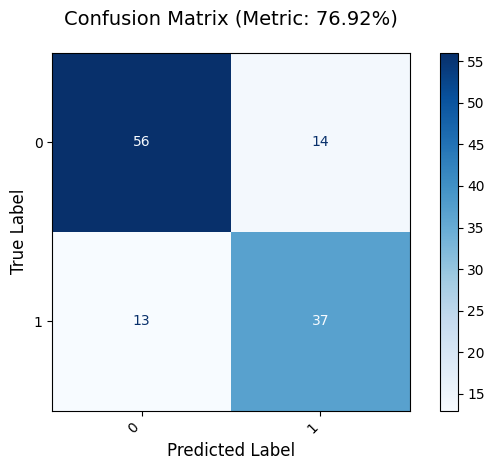


PER-CLASS METRICS
Class 0         | Precision: 0.8116 | Recall: 0.8000 | F1: 0.8058 | Support:   70
Class 1         | Precision: 0.7255 | Recall: 0.7400 | F1: 0.7327 | Support:   50


In [ ]:
# Evaluate on test set
test_metric.reset()

results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

# Save test evaluation results
with open(f"/content/model_res/test/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(results, f)

eval_results[MODEL_TYPE] = results

### Transfer-learning

In [ ]:
# Using pretrained ResNet with ImageNet weights
model = models.resnet18(weights="DEFAULT")

# Freeze backbone
for p in model.parameters():
  p.requires_grad = False

# Replace classifier with MLP and output NUM_CLASSES
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Paths
MODEL_TYPE = 'RESNET18_TL'
CHECKPOINT_FILE = f"/content/model_res/checkpoint_files/checkpoint_{MODEL_TYPE}.pt"

# Reset metrics
train_metric.reset()
val_metric.reset()

# Set up optimizer and scheduler
LEARNING_RATE = 1e-3 # Train MLP
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                             lr=LEARNING_RATE,
                             weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=3)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
model_results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    train_metric=train_metric,
    val_metric=val_metric,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    checkpoint_file=CHECKPOINT_FILE,
    report_interval=REPORT_INTERVAL
)

# Save results as .pkl
with open(f"/content/model_res/train_validation/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(model_results, f)

Epoch 1: Saved new best model (val_loss=0.5688)
Epoch 1/100 | Train loss: 0.6873, F1: 0.591 | Val loss: 0.5688, F1: 0.698


Epoch 2: No improvement (1/10)


Epoch 3: No improvement (2/10)


Epoch 4: No improvement (3/10)


Epoch 5: Saved new best model (val_loss=0.5415)
Epoch 5/100 | Train loss: 0.6100, F1: 0.682 | Val loss: 0.5415, F1: 0.687


...

Epoch 37: No improvement (6/10)


Epoch 38: No improvement (7/10)


Epoch 39: No improvement (8/10)


Epoch 40: No improvement (9/10)
Epoch 40/100 | Train loss: 0.4934, F1: 0.761 | Val loss: 0.5391, F1: 0.699


Epoch 41: No improvement (10/10)
Epoch 41: Early stopping triggered.


#### Evaluation

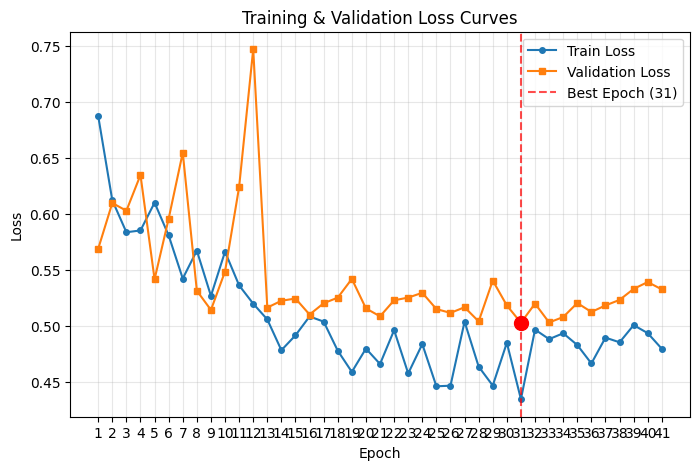

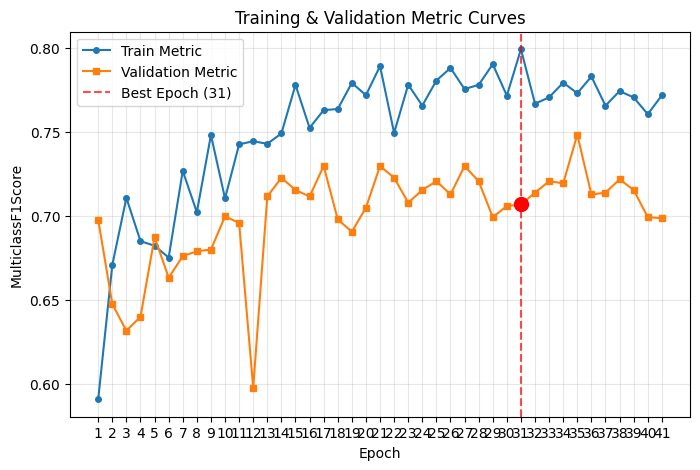

Best Epoch: 31 (Validation Loss:  0.5027115941047668 )


In [ ]:
# Loss and metric curves
loss_curves(model_results['train_losses'],
            model_results['val_losses'],
            model_results['train_metrics'],
            model_results['val_metrics'],
            best_epoch=model_results['best_epoch'],
            metric = metric_name)

print("Best Epoch:", model_results['best_epoch'] + 1,
      "(Validation Loss: ", model_results['best_val_loss'], ")")

Loading model from /content/model_res/checkpoint_files/checkpoint_RESNET18_TL.pt...
Best validation loss: 0.5027
Checkpoint from epoch: 31

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:03<00:00,  1.13it/s]


TEST RESULTS
Test Loss:   0.5056
Test Metric: 0.7463 (74.63%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.7500    0.9000    0.8182        70
     Class 1     0.8056    0.5800    0.6744        50

    accuracy                         0.7667       120
   macro avg     0.7778    0.7400    0.7463       120
weighted avg     0.7731    0.7667    0.7583       120



<Figure size 1000x800 with 0 Axes>

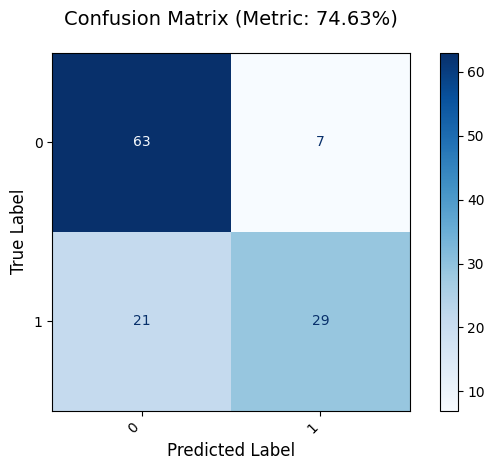


PER-CLASS METRICS
Class 0         | Precision: 0.7500 | Recall: 0.9000 | F1: 0.8182 | Support:   70
Class 1         | Precision: 0.8056 | Recall: 0.5800 | F1: 0.6744 | Support:   50


In [ ]:
# Evaluate on test set
test_metric.reset()

results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

# Save test evaluation results
with open(f"/content/model_res/test/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(results, f)

eval_results[MODEL_TYPE] = results

## ResNet50 architecture
- Extends ResNet18 with a deeper 50-later architecture with bottleneck residual blocks (reduces heavy computation at deeper layers)

### From scratch

In [ ]:
# Training ResNet model from scratch
model = models.resnet50(weights=None, num_classes=NUM_CLASSES)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Paths
MODEL_TYPE = 'RESNET50'
CHECKPOINT_FILE = f"/content/model_res/checkpoint_files/checkpoint_{MODEL_TYPE}.pt"

# Reset metrics
train_metric.reset()
val_metric.reset()

# Set up optimizer and scheduler
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                             lr=LEARNING_RATE,
                             weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=3)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
model_results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    train_metric=train_metric,
    val_metric=val_metric,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    checkpoint_file=CHECKPOINT_FILE,
    report_interval=REPORT_INTERVAL
)

# Save results as .pkl
with open(f"/content/model_res/train_validation/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(model_results, f)

Epoch 1: Saved new best model (val_loss=3.3311)
Epoch 1/100 | Train loss: 1.0414, F1: 0.562 | Val loss: 3.3311, F1: 0.519


Epoch 2: Saved new best model (val_loss=0.6750)


Epoch 3: No improvement (1/10)


Epoch 4: No improvement (2/10)


Epoch 5: No improvement (3/10)
Epoch 5/100 | Train loss: 0.7442, F1: 0.574 | Val loss: 0.6838, F1: 0.591


...

Epoch 14: No improvement (6/10)


Epoch 15: No improvement (7/10)
Epoch 15/100 | Train loss: 0.5975, F1: 0.687 | Val loss: 0.6773, F1: 0.641


Epoch 16: No improvement (8/10)


Epoch 17: No improvement (9/10)


Epoch 18: No improvement (10/10)
Epoch 18: Early stopping triggered.


#### Evaluation

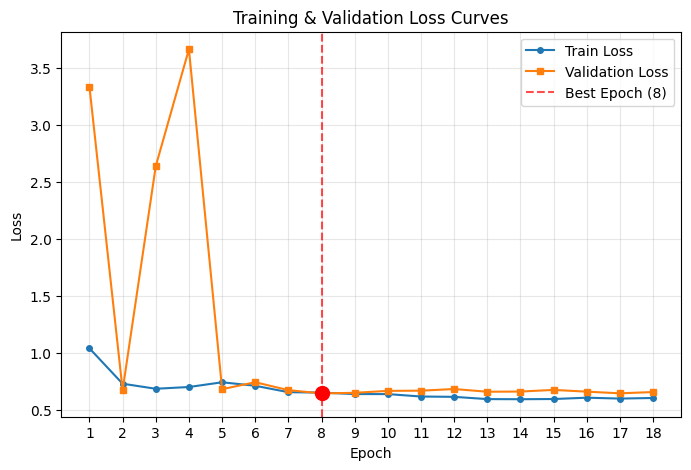

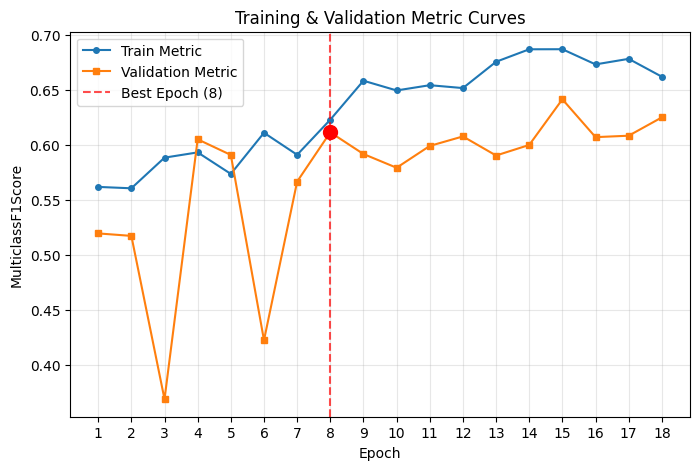

Best Epoch: 8 (Validation Loss:  0.6466457396745682 )


In [ ]:
# Loss and metric curves
loss_curves(model_results['train_losses'],
            model_results['val_losses'],
            model_results['train_metrics'],
            model_results['val_metrics'],
            best_epoch=model_results['best_epoch'],
            metric = metric_name)

print("Best Epoch:", model_results['best_epoch'] + 1,
      "(Validation Loss: ", model_results['best_val_loss'], ")")

Loading model from /content/model_res/checkpoint_files/checkpoint_RESNET50.pt...
Best validation loss: 0.6466
Checkpoint from epoch: 8

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:03<00:00,  1.04it/s]


TEST RESULTS
Test Loss:   0.6457
Test Metric: 0.6743 (67.43%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.7286    0.7286    0.7286        70
     Class 1     0.6200    0.6200    0.6200        50

    accuracy                         0.6833       120
   macro avg     0.6743    0.6743    0.6743       120
weighted avg     0.6833    0.6833    0.6833       120



<Figure size 1000x800 with 0 Axes>

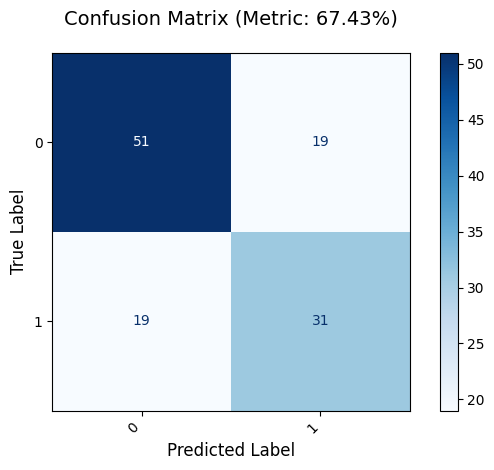


PER-CLASS METRICS
Class 0         | Precision: 0.7286 | Recall: 0.7286 | F1: 0.7286 | Support:   70
Class 1         | Precision: 0.6200 | Recall: 0.6200 | F1: 0.6200 | Support:   50


In [ ]:
# Evaluate on test set
test_metric.reset()

results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

# Save test evaluation results
with open(f"/content/model_res/test/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(results, f)

eval_results[MODEL_TYPE] = results

### Fine-tuning

In [ ]:
# Using pretrained ResNet with ImageNet weights
model = models.resnet50(weights="DEFAULT")

# Replace the final fully-connected layer to match the number of output classes for out dataset
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)
print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Paths
MODEL_TYPE = 'RESNET50_FineTuning'
CHECKPOINT_FILE = f"/content/model_res/checkpoint_files/checkpoint_{MODEL_TYPE}.pt"

# Reset metrics
train_metric.reset()
val_metric.reset()

# Set up optimizer and scheduler
LEARNING_RATE = 1e-4 # Reduced to minimize forgetting
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                             lr=LEARNING_RATE,
                             weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=3)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
model_results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    train_metric=train_metric,
    val_metric=val_metric,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    checkpoint_file=CHECKPOINT_FILE,
    report_interval=REPORT_INTERVAL
)

# Save results as .pkl
with open(f"/content/model_res/train_validation/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(model_results, f)

Epoch 1: Saved new best model (val_loss=0.5754)
Epoch 1/100 | Train loss: 0.6297, F1: 0.689 | Val loss: 0.5754, F1: 0.657


Epoch 2: Saved new best model (val_loss=0.5104)


Epoch 3: No improvement (1/10)


Epoch 4: No improvement (2/10)


Epoch 5: No improvement (3/10)
Epoch 5/100 | Train loss: 0.1138, F1: 0.971 | Val loss: 0.8319, F1: 0.700


...

Epoch 8: No improvement (6/10)


Epoch 9: No improvement (7/10)


Epoch 10: No improvement (8/10)
Epoch 10/100 | Train loss: 0.0488, F1: 0.996 | Val loss: 0.6301, F1: 0.821


Epoch 11: No improvement (9/10)


Epoch 12: No improvement (10/10)
Epoch 12: Early stopping triggered.


#### Evaluation

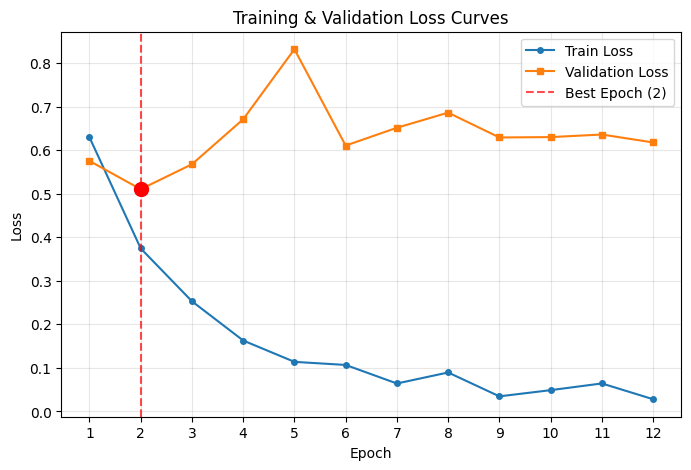

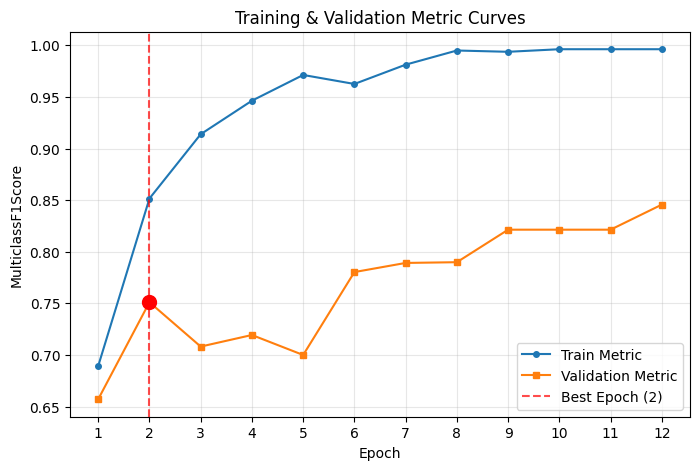

Best Epoch: 2 (Validation Loss:  0.5103622451424599 )


In [ ]:
# Loss and metric curves
loss_curves(model_results['train_losses'],
            model_results['val_losses'],
            model_results['train_metrics'],
            model_results['val_metrics'],
            best_epoch=model_results['best_epoch'],
            metric = metric_name)

print("Best Epoch:", model_results['best_epoch'] + 1,
      "(Validation Loss: ", model_results['best_val_loss'], ")")

Loading model from /content/model_res/checkpoint_files/checkpoint_RESNET50_FineTuning.pt...
Best validation loss: 0.5104
Checkpoint from epoch: 2

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:04<00:00,  1.13s/it]


TEST RESULTS
Test Loss:   0.5335
Test Metric: 0.7630 (76.30%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.7792    0.8571    0.8163        70
     Class 1     0.7674    0.6600    0.7097        50

    accuracy                         0.7750       120
   macro avg     0.7733    0.7586    0.7630       120
weighted avg     0.7743    0.7750    0.7719       120



<Figure size 1000x800 with 0 Axes>

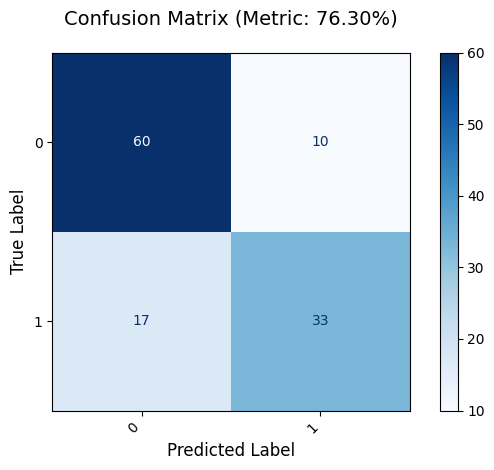


PER-CLASS METRICS
Class 0         | Precision: 0.7792 | Recall: 0.8571 | F1: 0.8163 | Support:   70
Class 1         | Precision: 0.7674 | Recall: 0.6600 | F1: 0.7097 | Support:   50


In [ ]:
# Evaluate on test set
test_metric.reset()

results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

# Save test evaluation results
with open(f"/content/model_res/test/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(results, f)

eval_results[MODEL_TYPE] = results

### Transfer-learning

In [ ]:
# Using pretrained ResNet with ImageNet weights
model = models.resnet50(weights="DEFAULT")

# Freeze backbone
for p in model.parameters():
  p.requires_grad = False

# Replace classifier with MLP and output NUM_CLASSES
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Paths
MODEL_TYPE = 'RESNET50_TL'
CHECKPOINT_FILE = f"/content/model_res/checkpoint_files/checkpoint_{MODEL_TYPE}.pt"

# Reset metrics
train_metric.reset()
val_metric.reset()

# Set up optimizer and scheduler
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
model_results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    train_metric=train_metric,
    val_metric=val_metric,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    checkpoint_file=CHECKPOINT_FILE,
    report_interval=REPORT_INTERVAL
)

# Save results as .pkl
with open(f"/content/model_res/train_validation/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(model_results, f)

Epoch 1: Saved new best model (val_loss=0.6641)
Epoch 1/100 | Train loss: 0.6328, F1: 0.617 | Val loss: 0.6641, F1: 0.600


Epoch 2: Saved new best model (val_loss=0.5312)


Epoch 3: No improvement (1/10)


Epoch 4: Saved new best model (val_loss=0.5054)


Epoch 5: No improvement (1/10)
Epoch 5/100 | Train loss: 0.4426, F1: 0.795 | Val loss: 0.5381, F1: 0.724


...

Epoch 10: No improvement (6/10)
Epoch 10/100 | Train loss: 0.3889, F1: 0.838 | Val loss: 0.5438, F1: 0.753


Epoch 11: No improvement (7/10)


Epoch 12: No improvement (8/10)


Epoch 13: No improvement (9/10)


Epoch 14: No improvement (10/10)
Epoch 14: Early stopping triggered.


#### Evaluation

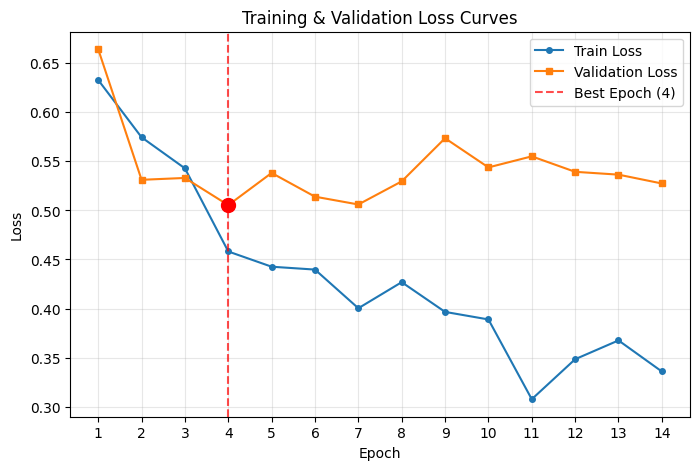

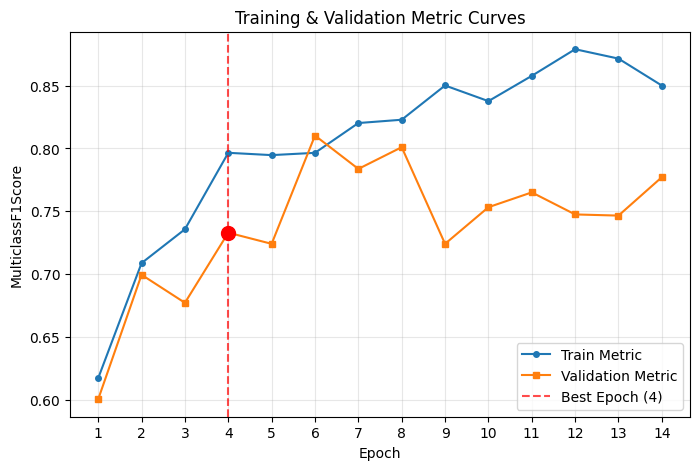

Best Epoch: 4 (Validation Loss:  0.5053664445877075 )


In [ ]:
# Loss and metric curves
loss_curves(model_results['train_losses'],
            model_results['val_losses'],
            model_results['train_metrics'],
            model_results['val_metrics'],
            best_epoch=model_results['best_epoch'],
            metric = metric_name)

print("Best Epoch:", model_results['best_epoch'] + 1,
      "(Validation Loss: ", model_results['best_val_loss'], ")")

Loading model from /content/model_res/checkpoint_files/checkpoint_RESNET50_TL.pt...
Best validation loss: 0.5054
Checkpoint from epoch: 4

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:03<00:00,  1.05it/s]


TEST RESULTS
Test Loss:   0.5067
Test Metric: 0.7176 (71.76%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.7294    0.8857    0.8000        70
     Class 1     0.7714    0.5400    0.6353        50

    accuracy                         0.7417       120
   macro avg     0.7504    0.7129    0.7176       120
weighted avg     0.7469    0.7417    0.7314       120



<Figure size 1000x800 with 0 Axes>

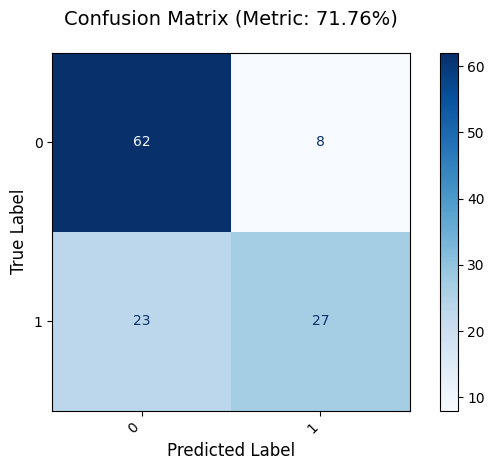


PER-CLASS METRICS
Class 0         | Precision: 0.7294 | Recall: 0.8857 | F1: 0.8000 | Support:   70
Class 1         | Precision: 0.7714 | Recall: 0.5400 | F1: 0.6353 | Support:   50


In [ ]:
# Evaluate on test set
test_metric.reset()

results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

# Save test evaluation results
with open(f"/content/model_res/test/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(results, f)

eval_results[MODEL_TYPE] = results

## EfficientNet architecture
- Family of CNNs that achieved state-of-the-art performance with fewer parameters and FLOPs (floating point operations) using compound scaling (jointly increase network depth, width and image resolution)

### From scratch

In [ ]:
# Training EfficientNet model from scratch
model = models.efficientnet_b0(weights=None, num_classes=NUM_CLASSES)
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# Paths
MODEL_TYPE = 'EFFICIENTNET_b0'
CHECKPOINT_FILE = f"/content/model_res/checkpoint_files/checkpoint_{MODEL_TYPE}.pt"

# Reset metrics
train_metric.reset()
val_metric.reset()

# Set up optimizer and scheduler
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                             lr=LEARNING_RATE,
                             weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=3)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
model_results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    train_metric=train_metric,
    val_metric=val_metric,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    checkpoint_file=CHECKPOINT_FILE,
    report_interval=REPORT_INTERVAL
)

# Save results as .pkl
with open(f"/content/model_res/train_validation/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(model_results, f)

Epoch 1: Saved new best model (val_loss=0.8987)
Epoch 1/100 | Train loss: 4.0154, F1: 0.534 | Val loss: 0.8987, F1: 0.368


Epoch 2: Saved new best model (val_loss=0.7378)


Epoch 3: No improvement (1/10)


Epoch 4: No improvement (2/10)


Epoch 5: No improvement (3/10)
Epoch 5/100 | Train loss: 1.4282, F1: 0.579 | Val loss: 1.7098, F1: 0.498


...

Epoch 8: No improvement (6/10)


Epoch 9: No improvement (7/10)


Epoch 10: No improvement (8/10)
Epoch 10/100 | Train loss: 1.0966, F1: 0.599 | Val loss: 1.8732, F1: 0.600


Epoch 11: No improvement (9/10)


Epoch 12: No improvement (10/10)
Epoch 12: Early stopping triggered.


#### Evaluation

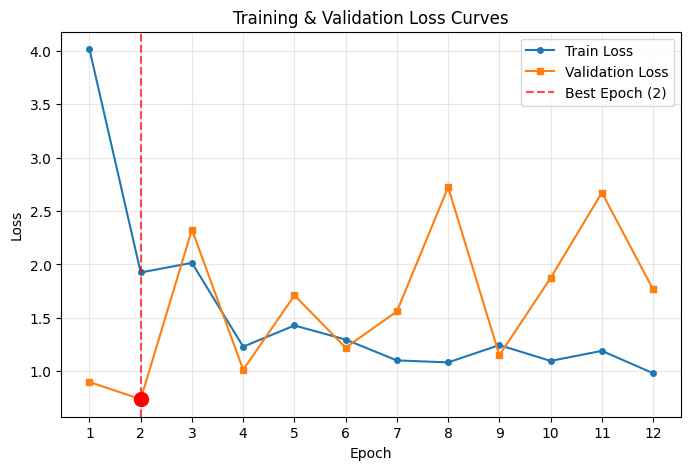

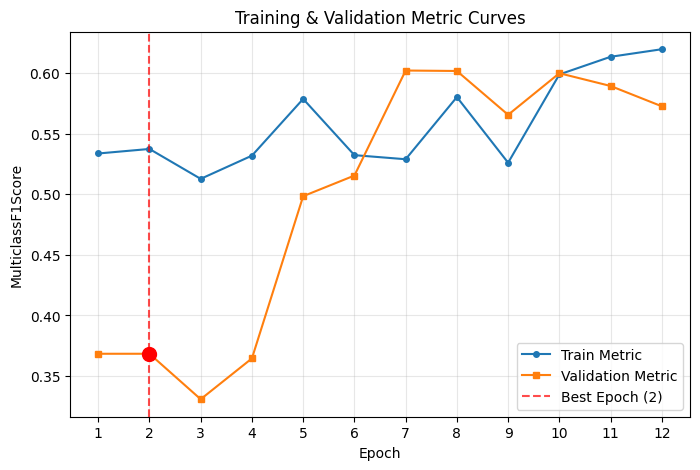

Best Epoch: 2 (Validation Loss:  0.7377729564905167 )


In [ ]:
# Loss and metric curves
loss_curves(model_results['train_losses'],
            model_results['val_losses'],
            model_results['train_metrics'],
            model_results['val_metrics'],
            best_epoch=model_results['best_epoch'],
            metric = metric_name)

print("Best Epoch:", model_results['best_epoch'] + 1,
      "(Validation Loss: ", model_results['best_val_loss'], ")")

Loading model from /content/model_res/checkpoint_files/checkpoint_EFFICIENTNET_b0.pt...
Best validation loss: 0.7378
Checkpoint from epoch: 2

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:03<00:00,  1.10it/s]


TEST RESULTS
Test Loss:   0.7377
Test Metric: 0.3684 (36.84%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.5833    1.0000    0.7368        70
     Class 1     0.0000    0.0000    0.0000        50

    accuracy                         0.5833       120
   macro avg     0.2917    0.5000    0.3684       120
weighted avg     0.3403    0.5833    0.4298       120




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 1000x800 with 0 Axes>

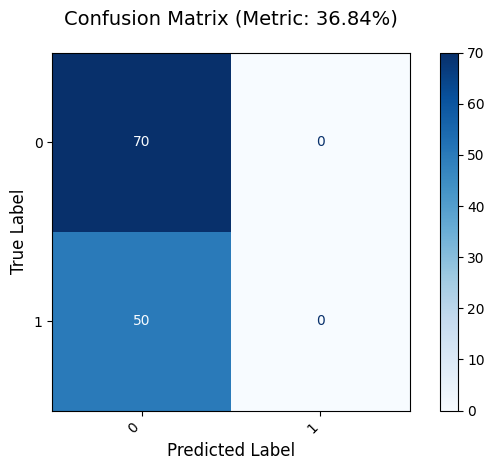


PER-CLASS METRICS
Class 0         | Precision: 0.5833 | Recall: 1.0000 | F1: 0.7368 | Support:   70
Class 1         | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000 | Support:   50


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Evaluate on test set
test_metric.reset()

results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

# Save test evaluation results
with open(f"/content/model_res/test/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(results, f)

eval_results[MODEL_TYPE] = results

### Fine-tuning

In [ ]:
# Using pretrained EfficientNet with ImageNet weights
model = models.efficientnet_b0(weights="DEFAULT")

# Replace the final fully-connected layer to match the number of output classes for our dataset
# EfficientNet models typically have a 'classifier' attribute, which is a Sequential module.
# The final linear layer is usually at index 1 of this Sequential module.
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, NUM_CLASSES)
print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 113MB/s] 


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# Paths
MODEL_TYPE = 'EFFICIENTNET_b0_FineTuning'
CHECKPOINT_FILE = f"/content/model_res/checkpoint_files/checkpoint_{MODEL_TYPE}.pt"

# Reset metrics
train_metric.reset()
val_metric.reset()

# Set up optimizer and scheduler
LEARNING_RATE = 1e-4 # Reduced to minimize forgetting
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                             lr=LEARNING_RATE,
                             weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=3)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
model_results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    train_metric=train_metric,
    val_metric=val_metric,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    checkpoint_file=CHECKPOINT_FILE,
    report_interval=REPORT_INTERVAL
)

# Save results as .pkl
with open(f"/content/model_res/train_validation/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(model_results, f)

Epoch 1: Saved new best model (val_loss=0.5909)
Epoch 1/100 | Train loss: 0.6390, F1: 0.637 | Val loss: 0.5909, F1: 0.658


Epoch 2: Saved new best model (val_loss=0.5080)


Epoch 3: Saved new best model (val_loss=0.4832)


Epoch 4: Saved new best model (val_loss=0.4377)


Epoch 5: Saved new best model (val_loss=0.4361)
Epoch 5/100 | Train loss: 0.2510, F1: 0.921 | Val loss: 0.4361, F1: 0.812


...

Epoch 12: No improvement (6/10)


Epoch 13: No improvement (7/10)


Epoch 14: No improvement (8/10)


Epoch 15: No improvement (9/10)
Epoch 15/100 | Train loss: 0.0910, F1: 0.981 | Val loss: 0.6262, F1: 0.763


Epoch 16: No improvement (10/10)
Epoch 16: Early stopping triggered.


#### Evaluation

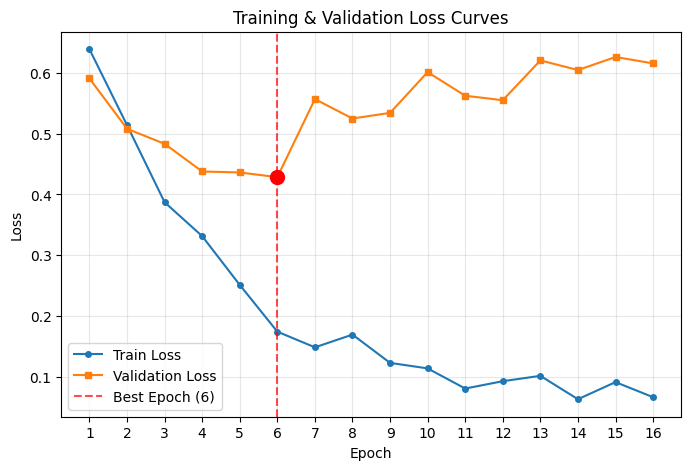

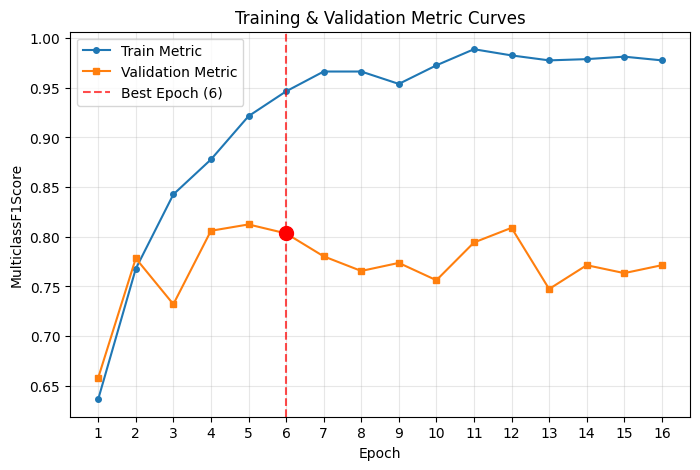

Best Epoch: 6 (Validation Loss:  0.42836491018533707 )


In [ ]:
# Loss and metric curves
loss_curves(model_results['train_losses'],
            model_results['val_losses'],
            model_results['train_metrics'],
            model_results['val_metrics'],
            best_epoch=model_results['best_epoch'],
            metric = metric_name)

print("Best Epoch:", model_results['best_epoch'] + 1,
      "(Validation Loss: ", model_results['best_val_loss'], ")")

Loading model from /content/model_res/checkpoint_files/checkpoint_EFFICIENTNET_b0_FineTuning.pt...
Best validation loss: 0.4284
Checkpoint from epoch: 6

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:03<00:00,  1.08it/s]


TEST RESULTS
Test Loss:   0.3993
Test Metric: 0.8124 (81.24%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.8529    0.8286    0.8406        70
     Class 1     0.7692    0.8000    0.7843        50

    accuracy                         0.8167       120
   macro avg     0.8111    0.8143    0.8124       120
weighted avg     0.8181    0.8167    0.8171       120



<Figure size 1000x800 with 0 Axes>

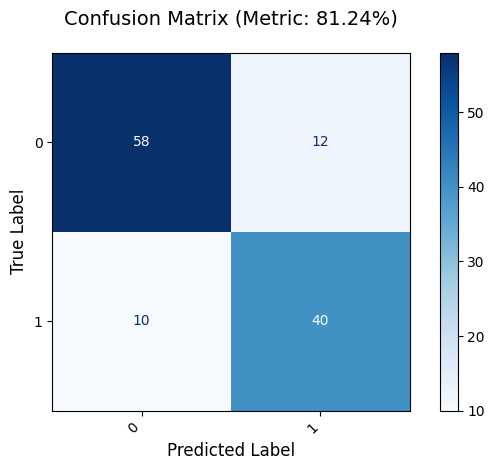


PER-CLASS METRICS
Class 0         | Precision: 0.8529 | Recall: 0.8286 | F1: 0.8406 | Support:   70
Class 1         | Precision: 0.7692 | Recall: 0.8000 | F1: 0.7843 | Support:   50


In [ ]:
# Evaluate on test set
test_metric.reset()

results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

# Save test evaluation results
with open(f"/content/model_res/test/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(results, f)

eval_results[MODEL_TYPE] = results

### Transfer learning

In [ ]:
# Using pretrained EfficientNet with ImageNet weights
model = models.efficientnet_b0(weights="DEFAULT")

# Freeze backbone
for p in model.parameters():
  p.requires_grad = False

# Replace classifier with MLP and output NUM_CLASSES
num_features = model.classifier[1].in_features # Get input features from the last linear layer
model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# Paths
MODEL_TYPE = 'EFFICIENTNET_b0_TL'
CHECKPOINT_FILE = f"/content/model_res/checkpoint_files/checkpoint_{MODEL_TYPE}.pt"

# Reset metrics
train_metric.reset()
val_metric.reset()

# Set up optimizer and scheduler
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                             lr=LEARNING_RATE,
                             weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=3)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
model_results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    train_metric=train_metric,
    val_metric=val_metric,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    checkpoint_file=CHECKPOINT_FILE,
    report_interval=REPORT_INTERVAL
)

# Save results as .pkl
with open(f"/content/model_res/train_validation/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(model_results, f)

Epoch 1: Saved new best model (val_loss=0.5732)
Epoch 1/100 | Train loss: 0.6384, F1: 0.623 | Val loss: 0.5732, F1: 0.661


Epoch 2: Saved new best model (val_loss=0.5548)


Epoch 3: Saved new best model (val_loss=0.5081)


Epoch 4: No improvement (1/10)


Epoch 5: No improvement (2/10)
Epoch 5/100 | Train loss: 0.4538, F1: 0.792 | Val loss: 0.5279, F1: 0.718


...

Epoch 9: No improvement (6/10)


Epoch 10: No improvement (7/10)
Epoch 10/100 | Train loss: 0.4029, F1: 0.845 | Val loss: 0.5334, F1: 0.697


Epoch 11: No improvement (8/10)


Epoch 12: No improvement (9/10)


Epoch 13: No improvement (10/10)
Epoch 13: Early stopping triggered.


#### Evaluation

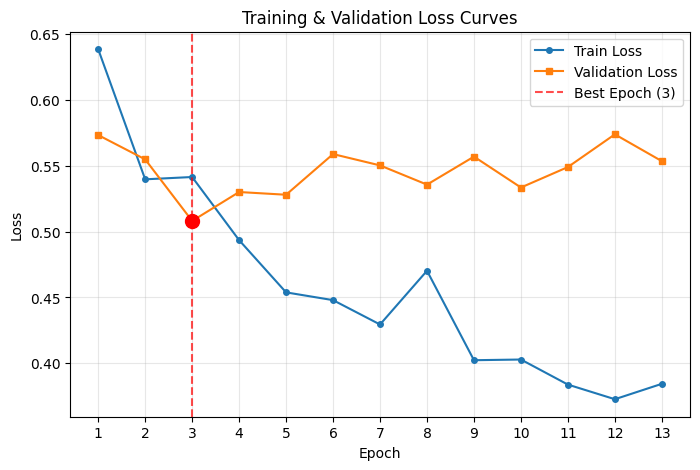

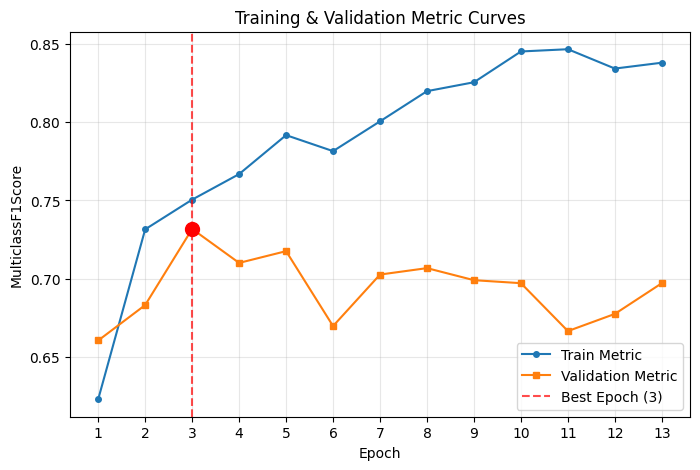

Best Epoch: 3 (Validation Loss:  0.508070632815361 )


In [ ]:
# Loss and metric curves
loss_curves(model_results['train_losses'],
            model_results['val_losses'],
            model_results['train_metrics'],
            model_results['val_metrics'],
            best_epoch=model_results['best_epoch'],
            metric = metric_name)

print("Best Epoch:", model_results['best_epoch'] + 1,
      "(Validation Loss: ", model_results['best_val_loss'], ")")

Loading model from /content/model_res/checkpoint_files/checkpoint_EFFICIENTNET_b0_TL.pt...
Best validation loss: 0.5081
Checkpoint from epoch: 3

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:04<00:00,  1.00s/it]


TEST RESULTS
Test Loss:   0.5209
Test Metric: 0.7335 (73.35%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.7746    0.7857    0.7801        70
     Class 1     0.6939    0.6800    0.6869        50

    accuracy                         0.7417       120
   macro avg     0.7343    0.7329    0.7335       120
weighted avg     0.7410    0.7417    0.7413       120



<Figure size 1000x800 with 0 Axes>

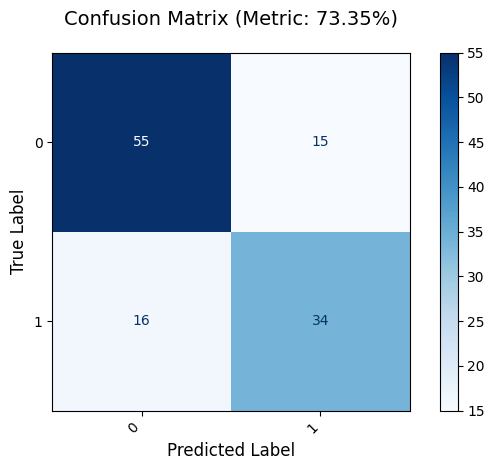


PER-CLASS METRICS
Class 0         | Precision: 0.7746 | Recall: 0.7857 | F1: 0.7801 | Support:   70
Class 1         | Precision: 0.6939 | Recall: 0.6800 | F1: 0.6869 | Support:   50


In [ ]:
# Evaluate on test set
test_metric.reset()

results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

# Save test evaluation results
with open(f"/content/model_res/test/results_{MODEL_TYPE}.pkl", "wb") as f:
  pickle.dump(results, f)

eval_results[MODEL_TYPE] = results

## Best model performance

In [ ]:
results_df = []

for key, item in eval_results.items():
  test_metric = item['test_metric']
  precision_0, precision_1 = item['precision']
  recall_0, recall_1 = item['recall']
  f1_0, f1_1 = item['f1_score']

  results_df.append([key, test_metric,
                     precision_0, precision_1,
                     recall_0, recall_1,
                     f1_0, f1_1])

results_df = pd.DataFrame(results_df, columns=['Model', 'F1_Macro',
                                               'Precision_C0', 'Precision_C1',
                                               'Recall_C0', 'Recall_C1',
                                               'F1_C0', 'F1_C1'])

In [ ]:
results_df.to_csv('/content/model_res/test/test_performance_results.csv', index=None)
results_df

,Model,F1_Macro,Precision_C0,Precision_C1,Recall_C0,Recall_C1,F1_C0,F1_C1
0,SimpleCNN,0.605003,0.662338,0.558140,0.728571,0.48,0.693878,0.516129
1,RESNET18,0.605014,0.688525,0.525424,0.600000,0.62,0.641221,0.568807
2,RESNET18_FineTuning,0.769214,0.811594,0.725490,0.800000,0.74,0.805755,0.732673
3,RESNET18_TL,0.746300,0.750000,0.805556,0.900000,0.58,0.818182,0.674419
4,RESNET50,0.674286,0.728571,0.620000,0.728571,0.62,0.728571,0.620000
5,RESNET50_FineTuning,0.763002,0.779221,0.767442,0.857143,0.66,0.816327,0.709677
6,RESNET50_TL,0.717647,0.729412,0.771429,0.885714,0.54,0.800000,0.635294
7,EFFICIENTNET_b0,0.368421,0.583333,0.000000,1.000000,0.00,0.736842,0.000000
8,EFFICIENTNET_b0_FineTuning,0.812447,0.852941,0.769231,0.828571,0.80,0.840580,0.784314
9,EFFICIENTNET_b0_TL,0.733505,0.774648,0.693878,0.785714,0.68,0.780142,0.686869


In [ ]:
results_df_long = results_df.melt(id_vars='Model', value_name='Score', var_name='Metric') # Long table
results_df_long

,Model,Metric,Score
0,SimpleCNN,F1_Macro,0.605003
1,RESNET18,F1_Macro,0.605014
2,RESNET18_FineTuning,F1_Macro,0.769214
3,RESNET18_TL,F1_Macro,0.746300
4,RESNET50,F1_Macro,0.674286
...,...,...,...
65,RESNET50_FineTuning,F1_C1,0.709677
66,RESNET50_TL,F1_C1,0.635294
67,EFFICIENTNET_b0,F1_C1,0.000000
68,EFFICIENTNET_b0_FineTuning,F1_C1,0.784314


<Figure size 1800x1800 with 0 Axes>

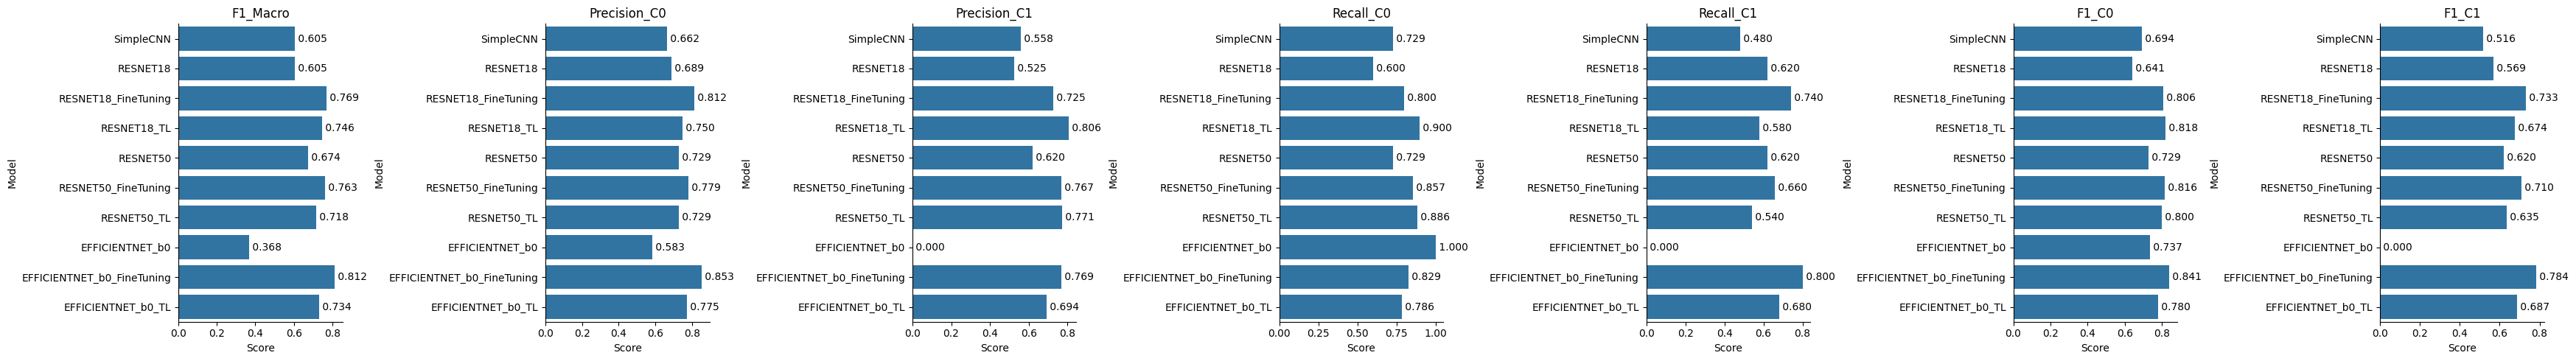

In [ ]:
plt.figure(figsize=(6,6), dpi=300)
metrics = results_df_long['Metric'].unique()
fig, axes = plt.subplots(1, len(metrics), figsize=(5*len(metrics), 5))

if len(metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics):
    metric_data = results_df_long[results_df_long['Metric'] == metric]
    sns.barplot(data=metric_data, y='Model', x='Score', ax=ax)
    ax.set_title(f'{metric}')

    # Add score labels on bars
    for i, (idx, row) in enumerate(metric_data.iterrows()):
        ax.text(row['Score'], i, f" {row['Score']:.3f}", va='center')

sns.despine()
plt.tight_layout()
plt.show()

## Error analysis

### Functions to assist

In [ ]:
!pip -q install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip -q install opencv-python
!pip -q install scikit-image
!pip -q install scipy


In [ ]:
import cv2
from scipy.ndimage import label as ndimage_label
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def collect_predictions(model, data_loader, device, mean=TRAIN_MEAN, std=TRAIN_STD):
    """
    Collect all predictions and separate into correctly and incorrectly classified samples.

    Args:
        model: PyTorch model to evaluate
        data_loader: DataLoader with images and labels
        device: Device to run inference on
        mean: Normalization mean
        std: Normalization standard deviation

    Returns:
        Dictionary containing:
            - 'correct_images': Tensor of correctly classified images
            - 'correct_labels': Tensor of true labels (correct)
            - 'correct_preds': Tensor of predicted labels (correct)
            - 'incorrect_images': Tensor of misclassified images
            - 'incorrect_labels': Tensor of true labels (incorrect)
            - 'incorrect_preds': Tensor of predicted labels (incorrect)
    """
    correct_images = []
    correct_labels = []
    correct_preds = []
    incorrect_images = []
    incorrect_labels = []
    incorrect_preds = []

    model.eval()
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct_idx = (preds == labels)
            incorrect_idx = (preds != labels)

            if correct_idx.any():
                correct_images.append(images[correct_idx].cpu())
                correct_labels.append(labels[correct_idx].cpu())
                correct_preds.append(preds[correct_idx].cpu())

            if incorrect_idx.any():
                incorrect_images.append(images[incorrect_idx].cpu())
                incorrect_labels.append(labels[incorrect_idx].cpu())
                incorrect_preds.append(preds[incorrect_idx].cpu())

    results = {}

    if correct_images:
        results['correct_images'] = torch.cat(correct_images, dim=0)
        results['correct_labels'] = torch.cat(correct_labels, dim=0)
        results['correct_preds'] = torch.cat(correct_preds, dim=0)
        print(f"Found {len(results['correct_images'])} correctly classified samples.")
    else:
        results['correct_images'] = None
        results['correct_labels'] = None
        results['correct_preds'] = None
        print("No correctly classified samples found.")

    if incorrect_images:
        results['incorrect_images'] = torch.cat(incorrect_images, dim=0)
        results['incorrect_labels'] = torch.cat(incorrect_labels, dim=0)
        results['incorrect_preds'] = torch.cat(incorrect_preds, dim=0)
        print(f"Found {len(results['incorrect_images'])} misclassified samples.")
    else:
        results['incorrect_images'] = None
        results['incorrect_labels'] = None
        results['incorrect_preds'] = None
        print("Great! No misclassified samples found.")

    return results

def compute_gradcam(model, input_tensor, target_layer, device):
    """
    Compute Grad-CAM heatmap using pytorch-grad-cam library.

    Args:
        model: PyTorch model
        input_tensor: Input image tensor [1, C, H, W]
        target_layer: Target layer (nn.Module) to compute gradients from
        device: Device (cpu/cuda)

    Returns:
        Heatmap array [H, W] normalized to [0, 1]
    """
    model.eval()
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=input_tensor)
    return grayscale_cam[0, :, :]  # Remove batch dimension

def plot_predictions(images, true_labels, predicted_labels, image_names=None,
                     model=None, target_layer=None, device=None,
                     num_to_show=20, mean=TRAIN_MEAN, std=TRAIN_STD,
                     class_names=None, show_gradcam=False, title_prefix=""):
    """
    Plot samples with optional Grad-CAM visualization and image names.

    Args:
        images: Tensor of images
        true_labels: Tensor of true labels
        predicted_labels: Tensor of predicted labels
        image_names: List of image file names (optional)
        model: PyTorch model (required if show_gradcam=True)
        target_layer: Target layer for Grad-CAM (required if show_gradcam=True)
        device: Device (required if show_gradcam=True)
        num_to_show: Number of samples to display
        mean: Normalization mean (optional)
        std: Normalization standard deviation (optional)
        class_names: Optional list of class names
        show_gradcam: Whether to compute and display Grad-CAM heatmaps
        title_prefix: Prefix for plot title (e.g., "Correctly" or "Incorrectly")
    """
    if images is None or len(images) == 0:
        print(f"No {title_prefix.lower()} classified images to display.")
        return

    if show_gradcam and (model is None or target_layer is None or device is None):
        print("Warning: model, target_layer, and device required for Grad-CAM. Skipping Grad-CAM.")
        show_gradcam = False

    num_to_show = min(num_to_show, len(images))
    cols = 2 if show_gradcam else 1
    rows = num_to_show

    plt.figure(figsize=(10 * cols if show_gradcam else 8, 5 * rows))

    for i in range(num_to_show):
        img = images[i]
        true_label = true_labels[i].item()
        pred_label = predicted_labels[i].item()
        image_name = image_names[i] if image_names else f"sample_{i}"

        img_display = tensor_to_rgb(img, mean, std)

        if class_names:
            true_name = class_names[true_label]
            pred_name = class_names[pred_label]
            title = f"{image_name}\nTrue: {true_name} | Pred: {pred_name}"
        else:
            title = f"{image_name}\nTrue: {true_label} | Pred: {pred_label}"

        if show_gradcam:
            # Original image (left)
            plt.subplot(rows, cols, i * cols + 1)
            plt.imshow(img_display)
            plt.title(title, color="red" if true_label != pred_label else "green",
                     fontweight="bold", fontsize=10)
            plt.axis("off")

            # Grad-CAM overlay (right)
            plt.subplot(rows, cols, i * cols + 2)
            img_tensor = img.unsqueeze(0).to(device)
            cam_heatmap = compute_gradcam(model, img_tensor, target_layer, device)
            overlaid = show_cam_on_image(img_display, cam_heatmap, use_rgb=True)
            plt.imshow(overlaid)
            plt.title(f"Grad-CAM", color="blue", fontweight="bold")
            plt.axis("off")
        else:
            # Original image only
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img_display)
            plt.title(title, color="red" if true_label != pred_label else "green",
                     fontweight="bold", fontsize=10)
            plt.axis("off")

    plt.suptitle(f"{title_prefix} Classified Samples" +
                 (" with Grad-CAM" if show_gradcam else ""),
                 fontsize=16, y=0.995)
    plt.tight_layout()
    plt.show()



In [ ]:
# Note: Functions re-structured and cleaned using Claude

# ============================================================================
# 1. CAM GENERATION
# ============================================================================

def generate_cam_for_batch(model, images, target_layer, device):
    """
    Generate Grad-CAM heatmaps for a batch of images.

    Args:
        model: PyTorch model
        images: Tensor of shape [B, C, H, W]
        target_layer: Target layer for Grad-CAM
        device: torch device

    Returns:
        numpy array of shape [B, H, W] with values in [0, 1]
    """
    model.eval()
    cam = GradCAM(model=model, target_layers=[target_layer])

    # GradCAM requires gradients, so don't use torch.no_grad() here
    grayscale_cam = cam(input_tensor=images)

    return grayscale_cam  # [B, H, W]


# ============================================================================
# 2. ANATOMICAL STRUCTURE DETECTION
# ============================================================================

def detect_disc_and_macula(img_rgb):
    """
    Automatically detect optic disc (bright region) and macula (dark region).

    Args:
        img_rgb: Image as numpy array with values in [0, 1], shape [H, W, 3]

    Returns:
        disc_mask: Binary mask of disc, shape [H, W]
        macula_mask: Binary mask of macula, shape [H, W]
    """
    img_gray = cv2.cvtColor((img_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    H, W = img_gray.shape
    blur = cv2.GaussianBlur(img_gray, (15, 15), 0)

    # Detect disc: brightest 2% -> largest connected component
    th_high = np.percentile(blur, 98)
    disc_bin = (blur >= th_high).astype(np.uint8)
    labels, num_features = ndimage_label(disc_bin)

    if num_features > 0:
        largest_label = np.argmax(np.bincount(labels.flat)[1:]) + 1
        disc_mask = (labels == largest_label).astype(np.uint8)
    else:
        disc_mask = np.zeros_like(disc_bin)

    # Detect macula: darkest 3% in center 40% region
    cy, cx = H // 2, W // 2
    roi = blur[int(cy - 0.2*H):int(cy + 0.2*H),
               int(cx - 0.2*W):int(cx + 0.2*W)]
    th_low = np.percentile(roi, 3)
    macula_mask = (blur <= th_low).astype(np.uint8)

    return disc_mask, macula_mask


def analyze_cam_regions(cam_heatmap, img_rgb):
    """
    Analyze CAM activation in anatomical regions.

    Args:
        cam_heatmap: CAM heatmap [H, W] with values in [0, 1]
        img_rgb: Original image [H, W, 3] with values in [0, 1]

    Returns:
        dict with keys: disc_ratio, macula_ratio, peak_region
    """
    disc_mask, macula_mask = detect_disc_and_macula(img_rgb)
    cam_bin = (cam_heatmap >= 0.5).astype(np.uint8)

    disc_ratio = (cam_bin * disc_mask).sum() / (disc_mask.sum() + 1e-6)
    macula_ratio = (cam_bin * macula_mask).sum() / (macula_mask.sum() + 1e-6)

    y_peak, x_peak = np.unravel_index(np.argmax(cam_heatmap), cam_heatmap.shape)
    if disc_mask[y_peak, x_peak]:
        peak_region = "disc"
    elif macula_mask[y_peak, x_peak]:
        peak_region = "macula"
    else:
        peak_region = "other"

    return {
        'disc_ratio': float(disc_ratio),
        'macula_ratio': float(macula_ratio),
        'peak_region': peak_region,
        'disc_mask': disc_mask,
        'macula_mask': macula_mask
    }


# ============================================================================
# 3. LESION MASK QUANTIFICATION
# ============================================================================

def load_binary_mask(mask_path, target_size_wh):
    """
    Load and resize binary mask for lesion.

    Args:
        mask_path: Path to mask file
        target_size_wh: Target size as (width, height)

    Returns:
        Binary mask as numpy array or None if file doesn't exist
    """
    if mask_path is None or not os.path.exists(mask_path):
        return None

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None

    mask = cv2.resize(mask, target_size_wh, interpolation=cv2.INTER_NEAREST)
    return (mask > 127).astype(np.uint8)


def compute_iou(cam_binary, lesion_mask):
    """
    Compute Intersection over Union (IoU) between CAM and lesion mask.

    Args:
        cam_binary: Binary CAM mask [H, W]
        lesion_mask: Binary lesion mask [H, W] or None

    Returns:
        IoU score in [0, 1] or NaN if mask is invalid
    """
    if lesion_mask is None or lesion_mask.sum() == 0:
        return np.nan

    intersection = (cam_binary & lesion_mask).sum()
    union = (cam_binary | lesion_mask).sum()
    return intersection / union if union > 0 else np.nan


def compute_pointing_hit(cam_heatmap, lesion_mask):
    """
    Check if CAM peak activation lands on lesion.

    Args:
        cam_heatmap: CAM heatmap [H, W]
        lesion_mask: Binary lesion mask [H, W] or None

    Returns:
        1.0 if peak is on lesion, 0.0 otherwise, NaN if mask is invalid
    """
    if lesion_mask is None or lesion_mask.sum() == 0:
        return np.nan

    y_peak, x_peak = np.unravel_index(np.argmax(cam_heatmap), cam_heatmap.shape)
    return 1.0 if lesion_mask[y_peak, x_peak] else 0.0


def analyze_lesion_alignment(cam_heatmap, img_shape, mask_root, stem):
    """
    Compute alignment metrics between CAM and lesion masks.

    Args:
        cam_heatmap: CAM heatmap [H, W]
        img_shape: (H, W) of image
        mask_root: Root directory containing lesion masks
        stem: Filename stem for loading masks

    Returns:
        dict with IoU and pointing metrics for each lesion type
    """
    H, W = img_shape
    cam_bin = (cam_heatmap >= 0.5).astype(np.uint8)

    lesion_types = ['microaneurysm', 'hemorrhage', 'exudate']
    results = {}

    for lesion_type in lesion_types:
        mask_path = os.path.join(mask_root, lesion_type, f"{stem}.png")
        mask = load_binary_mask(mask_path, (W, H))

        results[f'IoU_{lesion_type[:2].upper()}'] = compute_iou(cam_bin, mask)
        results[f'Point_{lesion_type[:2].upper()}'] = compute_pointing_hit(cam_heatmap, mask)

    return results


# ============================================================================
# 4. VISUALIZATION
# ============================================================================

def draw_contour_on_image(img_rgb, mask, color_rgb=(255, 0, 0), thickness=2):
    """
    Draw contour of mask on image.

    Args:
        img_rgb: Image [H, W, 3] with values in [0, 1]
        mask: Binary mask [H, W]
        color_rgb: Contour color as (R, G, B)
        thickness: Contour thickness

    Returns:
        Image with contour drawn, values in [0, 1]
    """
    if mask is None or mask.sum() == 0:
        return img_rgb

    mask_uint8 = (mask * 255).astype(np.uint8) if mask.max() <= 1 else mask.astype(np.uint8)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    img_uint8 = (img_rgb * 255).astype(np.uint8)
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
    cv2.drawContours(img_bgr, contours, -1, color_rgb[::-1], thickness)

    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0


def create_cam_panel(img_rgb, cam_overlay, cam_heatmap, region_analysis,
                     output_path=None, text_label=""):
    """
    Create side-by-side visualization: original | overlay | annotated.

    Args:
        img_rgb: Original image [H, W, 3] in [0, 1]
        cam_overlay: Grad-CAM overlay from show_cam_on_image
        cam_heatmap: Raw CAM heatmap [H, W]
        region_analysis: Dict from analyze_cam_regions()
        output_path: Path to save panel (optional)
        text_label: Text to overlay on panel

    Returns:
        Concatenated panel image
    """
    disc_mask = region_analysis['disc_mask']
    macula_mask = region_analysis['macula_mask']

    # Overlay contours on CAM visualization
    vis = cam_overlay.astype(np.float32) / 255.0 if cam_overlay.max() > 1 else cam_overlay.copy()
    vis = draw_contour_on_image(vis, disc_mask, color_rgb=(255, 0, 0), thickness=2)    # Red disc
    vis = draw_contour_on_image(vis, macula_mask, color_rgb=(0, 255, 0), thickness=2)  # Green macula

    # Concatenate: left=original | middle=overlay | right=annotated
    left = (img_rgb * 255).astype(np.uint8)
    middle = cam_overlay if cam_overlay.max() > 1 else (cam_overlay * 255).astype(np.uint8)
    right = (vis * 255).astype(np.uint8)

    panel = np.concatenate([left, middle, right], axis=1)

    # Add text annotation
    if text_label:
        panel_bgr = cv2.cvtColor(panel, cv2.COLOR_RGB2BGR)
        cv2.putText(panel_bgr, text_label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                   0.7, (10, 10, 240), 2, cv2.LINE_AA)
        panel = cv2.cvtColor(panel_bgr, cv2.COLOR_BGR2RGB)

    # Save if path provided
    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        cv2.imwrite(output_path, cv2.cvtColor(panel, cv2.COLOR_RGB2BGR))

    return panel


# ============================================================================
# 5. MAIN EVALUATION FUNCTION
# ============================================================================

def evaluate_cam_on_testloader(model, test_loader, target_layer, device,
                               output_dir="./cam_analysis",
                               mask_root=None, clinical_df=None,
                               image_col="IMAGE_NAME", stem_col=None,
                               save_panels=True, norm_mean=TRAIN_MEAN, norm_std=TRAIN_STD):
    """
    Generate CAM analysis for all samples in test_loader.

    Args:
        model: PyTorch model
        test_loader: DataLoader with (images, labels) and optional image_ids
        target_layer: Target layer for Grad-CAM
        device: torch device
        output_dir: Directory to save outputs
        mask_root: Root directory for lesion masks (optional)
        clinical_df: DataFrame with clinical labels (optional)
        image_col: Column name for image IDs in clinical_df
        stem_col: Column name for stems (defaults to stem of image_col)
        save_panels: Whether to save visualization panels
        norm_mean: Normalization mean. Required for denormalization (e.g., [0.485, 0.456, 0.406])
        norm_std: Normalization std. Required for denormalization (e.g., [0.229, 0.224, 0.225])

    Returns:
        DataFrame with CAM analysis results
    """
    os.makedirs(output_dir, exist_ok=True)

    records = []
    model.eval()

    for batch_idx, batch_data in enumerate(test_loader):
        # Handle different batch formats
        if len(batch_data) == 2:
            images, labels = batch_data
            image_paths = [f"sample_{batch_idx}_{i}" for i in range(len(images))]
        elif len(batch_data) == 3:
            images, labels, image_paths = batch_data
        else:
            raise ValueError(f"Unexpected batch format with {len(batch_data)} elements")

        images = images.to(device)
        B, C, H, W = images.shape

        with torch.no_grad():
            # Generate predictions
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

        # Generate CAM (requires gradients)
        cam_heatmaps = generate_cam_for_batch(model, images, target_layer, device)

        # Convert images to CPU for visualization
        images_cpu = images.cpu().detach()

        # Process each sample in batch
        for i in range(B):
            img_tensor = images_cpu[i]  # [C, H, W]

            # Denormalize using tensor_to_rgb
            if norm_mean is not None and norm_std is not None:
                img_rgb = tensor_to_rgb(img_tensor, norm_mean, norm_std)
            else:
                img_rgb = img_tensor.permute(1, 2, 0).numpy()
                img_rgb = np.clip(img_rgb, 0, 1)

            cam_heatmap = cam_heatmaps[i]  # [H, W]
            true_label = labels[i].item()
            pred_label = preds[i].item()
            image_id = str(image_paths[i]) if isinstance(image_paths, (list, tuple)) else f"{image_paths[i]}"
            stem = os.path.splitext(os.path.basename(image_id))[0]

            # Create record
            record = {
                'stem': stem,
                'image_id': image_id,
                'y_true': true_label,
                'y_pred': pred_label,
                'correct': true_label == pred_label,
            }

            # Global CAM metrics
            cam_bin = (cam_heatmap >= 0.5).astype(np.uint8)
            record['CAM_area_ratio'] = float(cam_bin.mean())
            record['CAM_peak_intensity'] = float(cam_heatmap.max())

            # Anatomical region analysis
            region_analysis = analyze_cam_regions(cam_heatmap, img_rgb)
            record.update({
                f'CAM_in_{k}': v for k, v in region_analysis.items()
                if k != 'disc_mask' and k != 'macula_mask'
            })

            # Lesion mask analysis
            if mask_root is not None:
                lesion_metrics = analyze_lesion_alignment(cam_heatmap, img_rgb.shape[:2],
                                                          mask_root, stem)
                record.update(lesion_metrics)

            # Generate visualization
            if save_panels:
                # Use tensor_to_rgb for proper denormalization if parameters provided
                if norm_mean is not None and norm_std is not None:
                    img_for_panel = tensor_to_rgb(img_tensor, norm_mean, norm_std)
                else:
                    img_for_panel = img_rgb

                cam_overlay = show_cam_on_image(img_for_panel, cam_heatmap, use_rgb=True)
                text = f"T:{true_label} P:{pred_label} | Peak:{region_analysis['peak_region']}"
                panel_path = os.path.join(output_dir, f"{stem}_panel.jpg")
                create_cam_panel(img_for_panel, cam_overlay, cam_heatmap, region_analysis,
                                output_path=panel_path, text_label=text)
                record['panel_path'] = panel_path

            records.append(record)

    # Create results DataFrame
    df_results = pd.DataFrame(records)

    # Merge with clinical labels if provided
    if clinical_df is not None:
        if stem_col is None:
            stem_col = image_col

        clinical_df_copy = clinical_df.copy()
        clinical_df_copy['stem'] = clinical_df_copy[image_col].apply(
            lambda x: os.path.splitext(str(x))[0]
        )
        df_results = df_results.merge(
            clinical_df_copy[['stem'] + [col for col in clinical_df_copy.columns
                                          if col not in ['stem', image_col]]],
            on='stem', how='left'
        )

    # Save results
    output_csv = os.path.join(output_dir, "cam_analysis_report.csv")
    df_results.to_csv(output_csv, index=False)
    print(f"✅ CAM analysis saved to: {output_dir}")
    print(f"   Report: {output_csv}")
    print(f"   Total samples: {len(df_results)}")
    print(f"   Correct predictions: {df_results['correct'].sum()}")

    return df_results

### Inspecting misclassifications

In [ ]:
# Re-initialize the best model - EfficientNet b0
model = models.efficientnet_b0(weights="DEFAULT")
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, NUM_CLASSES)

MODEL_TYPE = 'EFFICIENTNET_b0_FineTuning'
checkpoint = torch.load(f"/content/model_res/checkpoint_files/checkpoint_{MODEL_TYPE}.pt", map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model = model.to(DEVICE)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# Collect and visualize the misclassified samples with Grad-CAM
pred_results = collect_predictions(model, test_loader, DEVICE)
# target_layer = model.layer4[-1] # Last convolutional layer (ResNet)
target_layer = model.features[-1]

Found 98 correctly classified samples.
Found 22 misclassified samples.


In [ ]:
pred_results.keys()

dict_keys(['correct_images', 'correct_labels', 'correct_preds', 'incorrect_images', 'incorrect_labels', 'incorrect_preds'])

In [ ]:
# Misclassified samples
plot_predictions(pred_results['incorrect_images'],
                 pred_results['incorrect_labels'],
                 pred_results['incorrect_preds'],
                 model=model, target_layer=target_layer, device=DEVICE,
                 show_gradcam=True, title_prefix="Misclassified")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Correctly classified samples
plot_predictions(pred_results['correct_images'],
                 pred_results['correct_labels'],
                 pred_results['correct_preds'],
                 model=model, target_layer=target_layer, device=DEVICE,
                 show_gradcam=True, title_prefix="Correctly")

Output hidden; open in https://colab.research.google.com to view.

### MAPLES-DR Annotations

In [ ]:
df_cam = evaluate_cam_on_testloader(
    model=model,
    test_loader=test_loader,
    target_layer=target_layer,
    device=DEVICE,
    output_dir="/content/model_res/cam_analysis",
    image_col="IMAGE_NAME"
)

✅ CAM analysis saved to: /content/model_res/cam_analysis
   Report: /content/model_res/cam_analysis/cam_analysis_report.csv
   Total samples: 120
   Correct predictions: 98


In [ ]:
# Merge CAM analysis report with test_df details
df_cam_testdf = pd.concat([df_cam, test_df.reset_index(drop=True)], axis=1)
df_cam_testdf.to_csv('/content/model_res/cam_analysis/cam_analysis_report.csv', index=None)

In [ ]:
df_cam_testdf.head(5)

,stem,image_id,y_true,y_pred,correct,CAM_area_ratio,CAM_peak_intensity,CAM_in_disc_ratio,CAM_in_macula_ratio,CAM_in_peak_region,panel_path,IMAGE_NAME,SOURCE,RETINOPATHY_GRADE,MACULAR_EDEMA_RISK,SUB_DIR,BINARY_GRADE
0,sample_0_0,sample_0_0,1,1,True,0.134387,1.0,0.00000,0.000000,other,/content/model_res/cam_analysis/sample_0_0_pan...,20051202_54611_0400_PP.tif,LaTIM - CHU de BREST,2,1,Base33,1
1,sample_0_1,sample_0_1,1,1,True,0.062181,1.0,0.00000,0.026703,other,/content/model_res/cam_analysis/sample_0_1_pan...,20051214_40912_0100_PP.tif,Service Ophtalmologie Lariboisière,3,1,Base12,1
2,sample_0_2,sample_0_2,0,0,True,0.122768,1.0,0.43453,0.029677,other,/content/model_res/cam_analysis/sample_0_2_pan...,20060523_48890_0100_PP.tif,Service Ophtalmologie Lariboisière,0,0,Base13,0
3,sample_0_3,sample_0_3,1,1,True,0.373724,1.0,0.37355,0.160879,other,/content/model_res/cam_analysis/sample_0_3_pan...,20060523_50489_0100_PP.tif,Service Ophtalmologie Lariboisière,3,0,Base14,1
4,sample_0_4,sample_0_4,0,0,True,0.076849,1.0,1.00000,0.000000,disc,/content/model_res/cam_analysis/sample_0_4_pan...,20051216_45781_0200_PP.tif,CHU de St Etienne,0,0,Base21,0


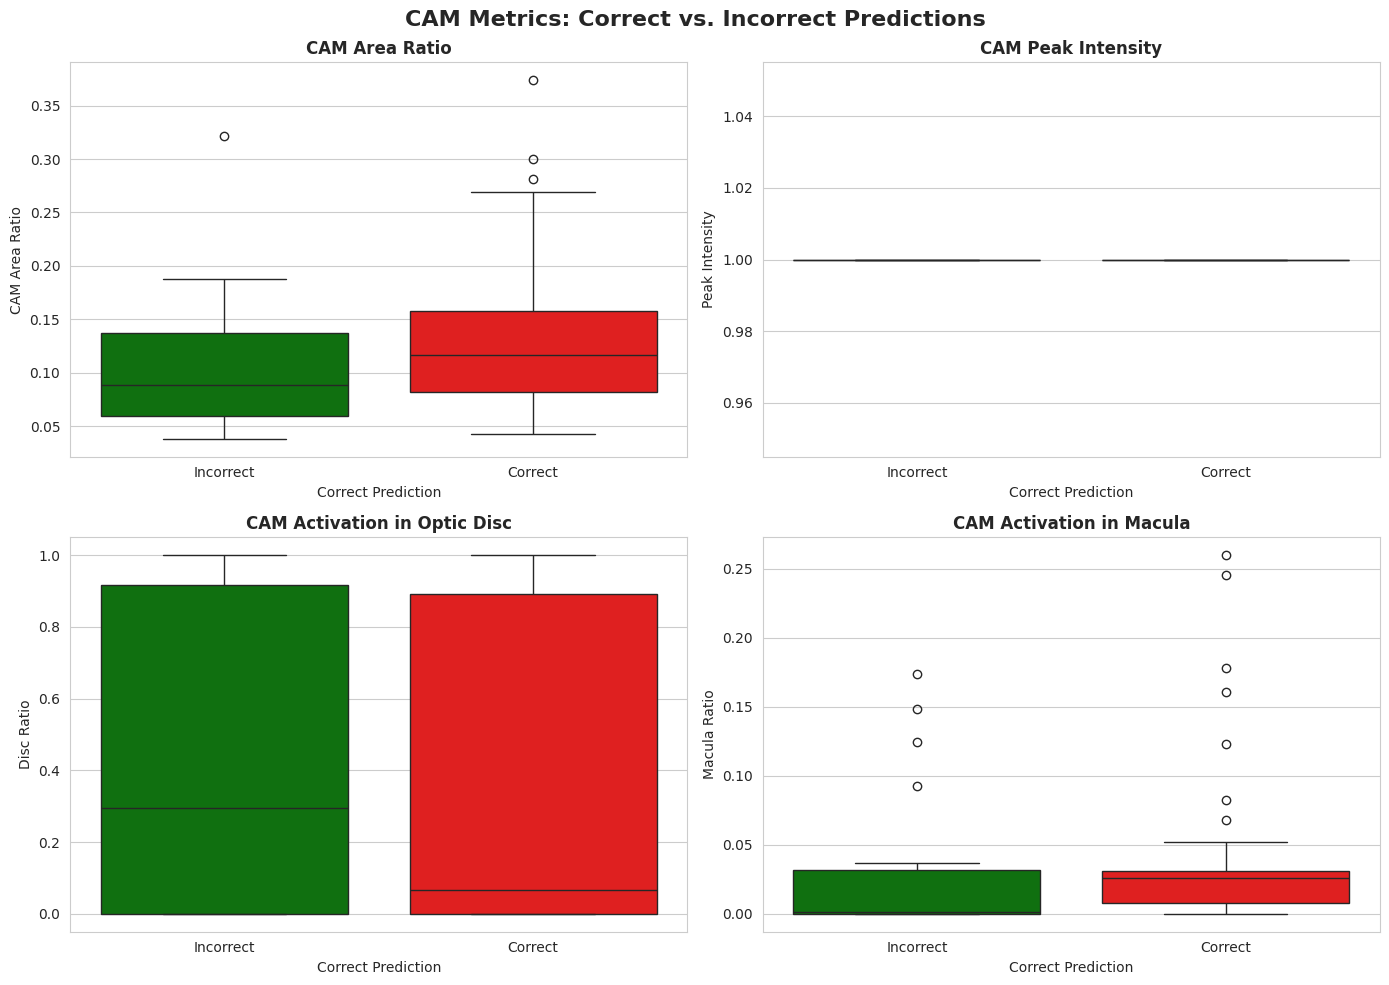

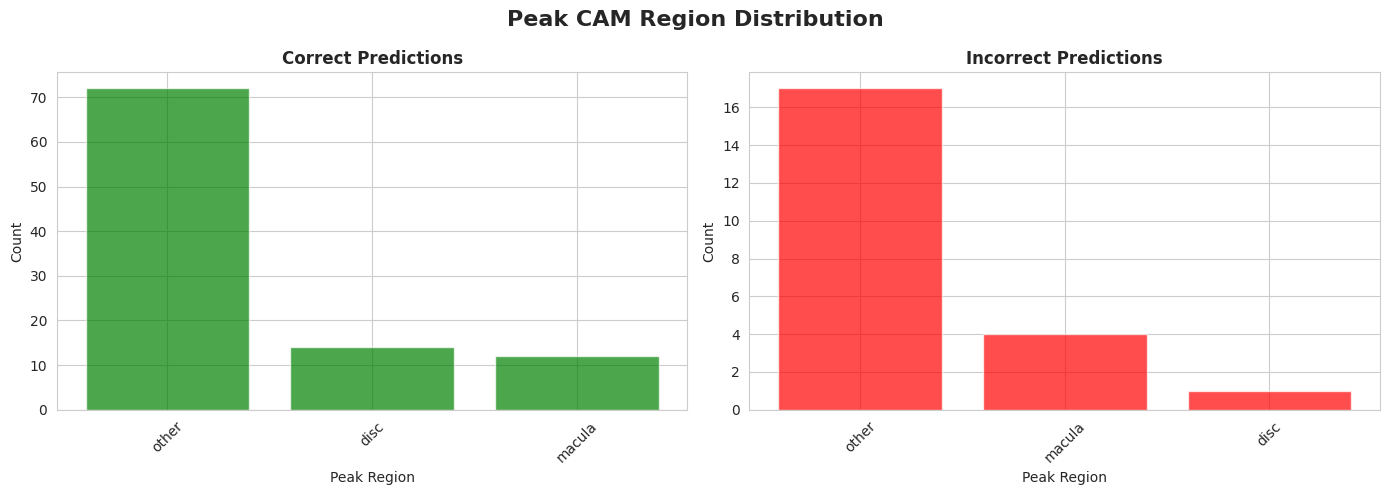

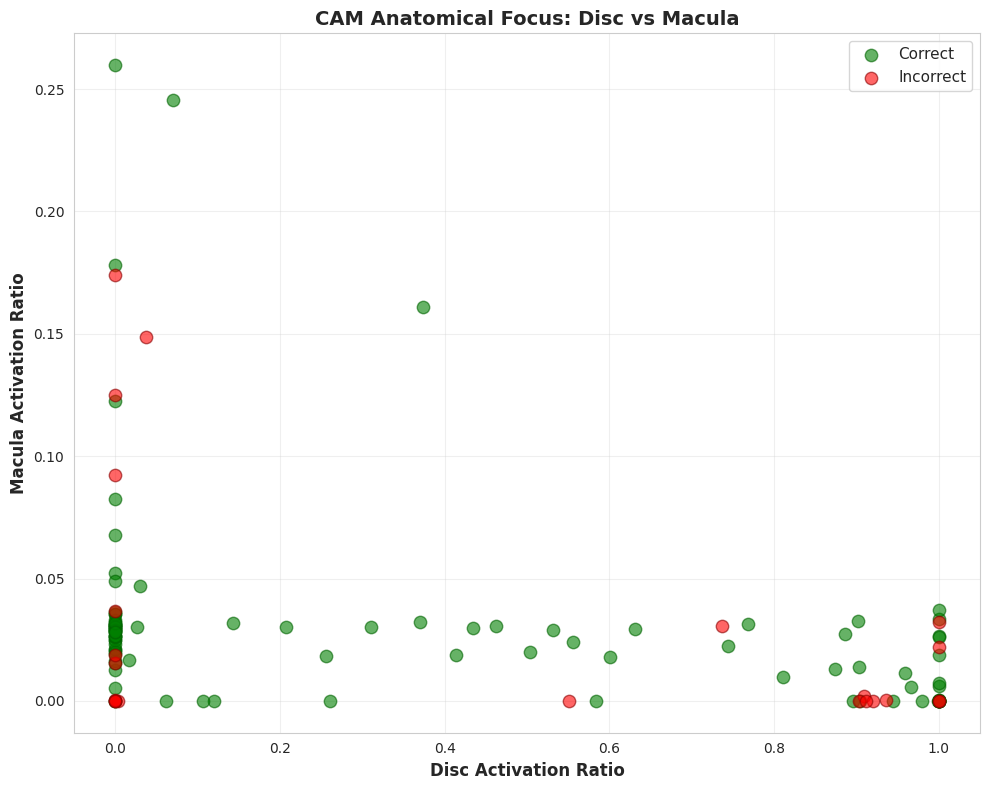

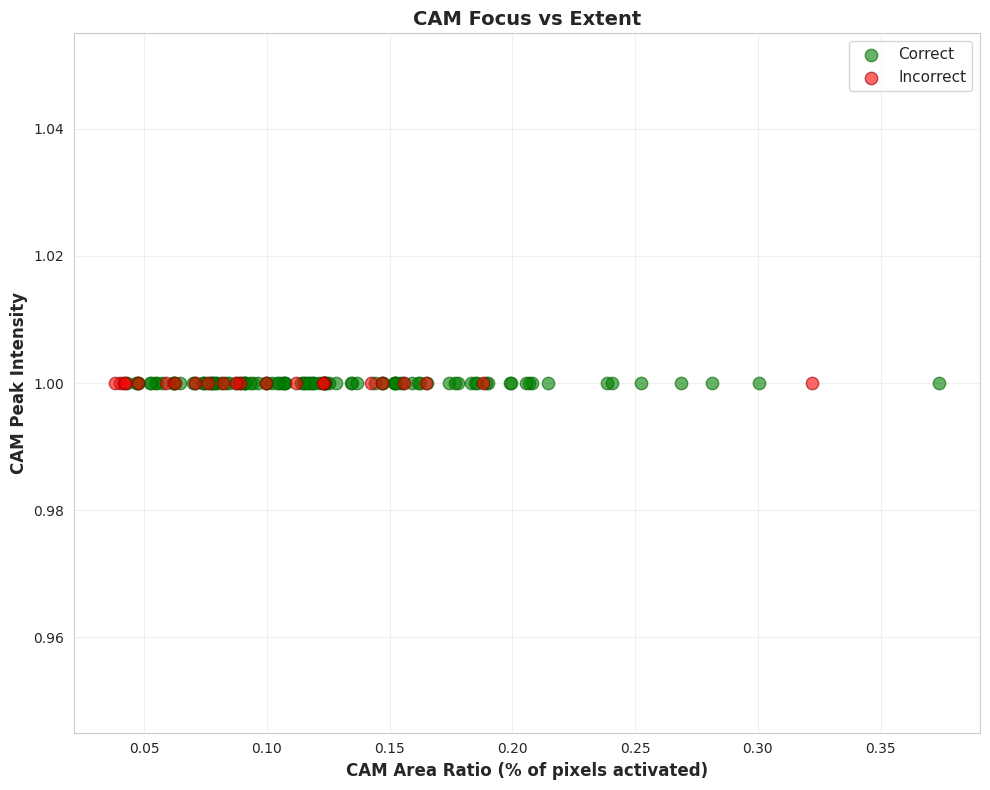

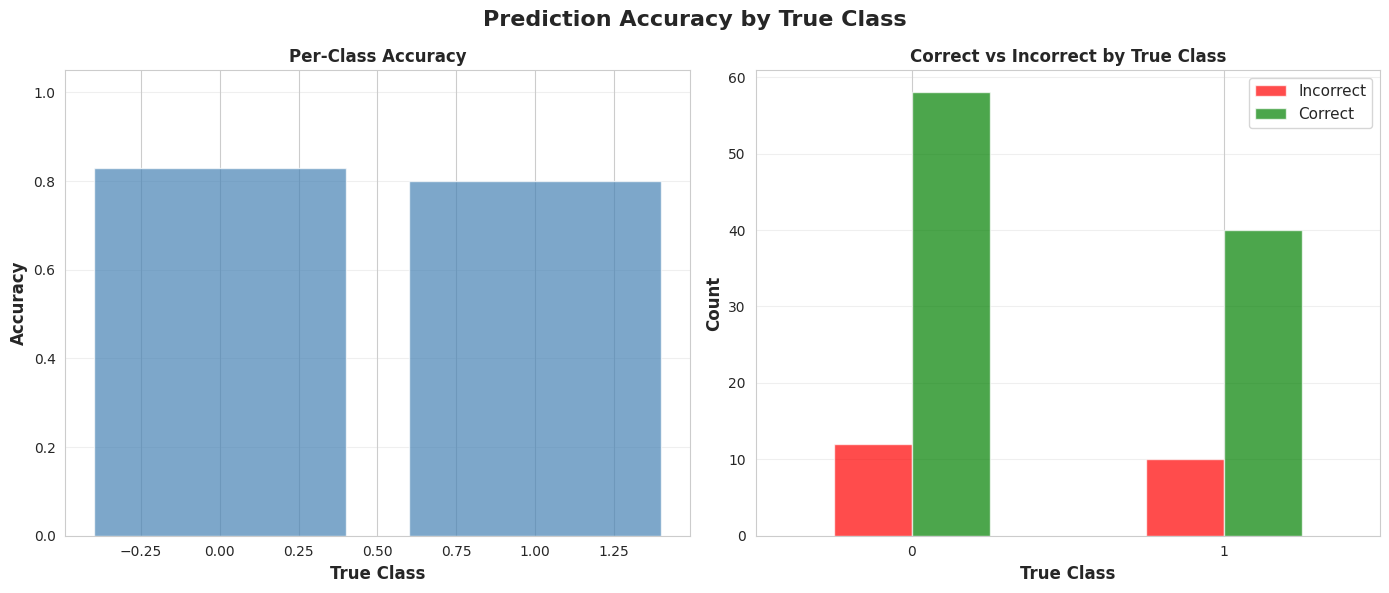

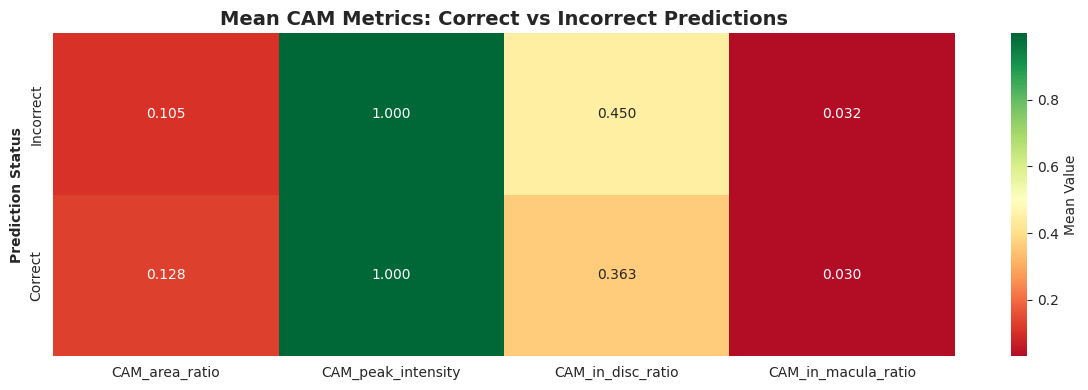


CAM ANALYSIS SUMMARY STATISTICS

Total Samples: 120
Correct Predictions: 98 (81.7%)
Incorrect Predictions: 22 (18.3%)

--------------------------------------------------------------------------------
CAM METRICS COMPARISON
--------------------------------------------------------------------------------
        CAM_area_ratio                                                    \
                 count      mean       std       min       25%       50%   
correct                                                                    
False             22.0  0.105175  0.065796  0.038245  0.059869  0.088259   
True              98.0  0.127939  0.061709  0.042949  0.081608  0.116918   

                            CAM_peak_intensity       ... CAM_in_disc_ratio  \
              75%       max              count mean  ...               75%   
correct                                              ...                     
False    0.137471  0.321987               22.0  1.0  ...          0.917851   
Tr

In [ ]:
# Investigate if there are any interesting trends between those that were predicted correctly vs incorrectly

df = df_cam_testdf.copy()

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# ============================================================================
# 1. CAM METRICS BY CORRECTNESS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CAM Metrics: Correct vs. Incorrect Predictions', fontsize=16, fontweight='bold')

# CAM Area Ratio
sns.boxplot(data=df, x='correct', y='CAM_area_ratio', ax=axes[0, 0], hue='correct', palette=['green', 'red'])
axes[0, 0].set_title('CAM Area Ratio', fontweight='bold')
axes[0, 0].set_xlabel('Correct Prediction')
axes[0, 0].set_ylabel('CAM Area Ratio')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Incorrect', 'Correct'])
axes[0, 0].legend_.remove()

# CAM Peak Intensity
sns.boxplot(data=df, x='correct', y='CAM_peak_intensity', ax=axes[0, 1], hue='correct', palette=['green', 'red'])
axes[0, 1].set_title('CAM Peak Intensity', fontweight='bold')
axes[0, 1].set_xlabel('Correct Prediction')
axes[0, 1].set_ylabel('Peak Intensity')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Incorrect', 'Correct'])
axes[0, 1].legend_.remove()

# CAM in Disc Ratio
sns.boxplot(data=df, x='correct', y='CAM_in_disc_ratio', ax=axes[1, 0], hue='correct', palette=['green', 'red'])
axes[1, 0].set_title('CAM Activation in Optic Disc', fontweight='bold')
axes[1, 0].set_xlabel('Correct Prediction')
axes[1, 0].set_ylabel('Disc Ratio')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['Incorrect', 'Correct'])
axes[1, 0].legend_.remove()

# CAM in Macula Ratio
sns.boxplot(data=df, x='correct', y='CAM_in_macula_ratio', ax=axes[1, 1], hue='correct', palette=['green', 'red'])
axes[1, 1].set_title('CAM Activation in Macula', fontweight='bold')
axes[1, 1].set_xlabel('Correct Prediction')
axes[1, 1].set_ylabel('Macula Ratio')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Incorrect', 'Correct'])
axes[1, 1].legend_.remove()

plt.tight_layout()
plt.show()

# ============================================================================
# 2. ANATOMICAL FOCUS REGION DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Peak CAM Region Distribution', fontsize=16, fontweight='bold')

# Count peak regions for correct predictions
correct_peaks = df[df['correct']]['CAM_in_peak_region'].value_counts()
axes[0].bar(correct_peaks.index, correct_peaks.values, color='green', alpha=0.7)
axes[0].set_title('Correct Predictions', fontweight='bold')
axes[0].set_xlabel('Peak Region')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Count peak regions for incorrect predictions
incorrect_peaks = df[~df['correct']]['CAM_in_peak_region'].value_counts()
axes[1].bar(incorrect_peaks.index, incorrect_peaks.values, color='red', alpha=0.7)
axes[1].set_title('Incorrect Predictions', fontweight='bold')
axes[1].set_xlabel('Peak Region')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================================================
# 3. DISC vs MACULA ACTIVATION SCATTER PLOT
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 8))

correct_mask = df['correct']
ax.scatter(df.loc[correct_mask, 'CAM_in_disc_ratio'],
           df.loc[correct_mask, 'CAM_in_macula_ratio'],
           label='Correct', alpha=0.6, s=80, color='green', edgecolors='darkgreen', linewidth=1)
ax.scatter(df.loc[~correct_mask, 'CAM_in_disc_ratio'],
           df.loc[~correct_mask, 'CAM_in_macula_ratio'],
           label='Incorrect', alpha=0.6, s=80, color='red', edgecolors='darkred', linewidth=1)

ax.set_xlabel('Disc Activation Ratio', fontsize=12, fontweight='bold')
ax.set_ylabel('Macula Activation Ratio', fontsize=12, fontweight='bold')
ax.set_title('CAM Anatomical Focus: Disc vs Macula', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 4. LESION ALIGNMENT - IoU METRICS BY CORRECTNESS
# ============================================================================

# Check which lesion IoU columns are available
lesion_iou_cols = [col for col in df.columns if col.startswith('IoU_')]

if lesion_iou_cols:
    fig, axes = plt.subplots(1, len(lesion_iou_cols), figsize=(5*len(lesion_iou_cols), 6))
    if len(lesion_iou_cols) == 1:
        axes = [axes]

    fig.suptitle('Lesion Alignment - Intersection over Union (IoU)', fontsize=16, fontweight='bold')

    for idx, col in enumerate(lesion_iou_cols):
        sns.boxplot(data=df, x='correct', y=col, ax=axes[idx], palette=['green', 'red'])
        axes[idx].set_title(col.replace('IoU_', ''), fontweight='bold', fontsize=12)
        axes[idx].set_xlabel('Correct Prediction')
        axes[idx].set_ylabel('IoU Score')
        axes[idx].set_xticklabels(['Incorrect', 'Correct'])
        axes[idx].set_ylim([-0.05, 1.05])

    plt.tight_layout()
    plt.show()

# ============================================================================
# 5. LESION POINTING HIT RATES
# ============================================================================

# Check which pointing hit columns are available
point_cols = [col for col in df.columns if col.startswith('Point_')]

if point_cols:
    fig, ax = plt.subplots(figsize=(10, 6))

    pointing_stats = []
    for col in point_cols:
        lesion_name = col.replace('Point_', '')
        correct_hit_rate = df[df['correct']][col].mean()
        incorrect_hit_rate = df[~df['correct']][col].mean()
        pointing_stats.append({
            'Lesion': lesion_name,
            'Correct': correct_hit_rate,
            'Incorrect': incorrect_hit_rate
        })

    stats_df = pd.DataFrame(pointing_stats)
    x = np.arange(len(stats_df))
    width = 0.35

    ax.bar(x - width/2, stats_df['Correct'], width, label='Correct', color='green', alpha=0.7)
    ax.bar(x + width/2, stats_df['Incorrect'], width, label='Incorrect', color='red', alpha=0.7)

    ax.set_xlabel('Lesion Type', fontweight='bold', fontsize=12)
    ax.set_ylabel('Peak Pointing Hit Rate', fontweight='bold', fontsize=12)
    ax.set_title('CAM Peak Activation on Lesion (Pointing Hit Rate)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(stats_df['Lesion'])
    ax.legend(fontsize=11)
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================================
# 6. CAM PEAK INTENSITY vs CAM AREA RATIO
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 8))

correct_mask = df['correct']
ax.scatter(df.loc[correct_mask, 'CAM_area_ratio'],
           df.loc[correct_mask, 'CAM_peak_intensity'],
           label='Correct', alpha=0.6, s=80, color='green', edgecolors='darkgreen', linewidth=1)
ax.scatter(df.loc[~correct_mask, 'CAM_area_ratio'],
           df.loc[~correct_mask, 'CAM_peak_intensity'],
           label='Incorrect', alpha=0.6, s=80, color='red', edgecolors='darkred', linewidth=1)

ax.set_xlabel('CAM Area Ratio (% of pixels activated)', fontsize=12, fontweight='bold')
ax.set_ylabel('CAM Peak Intensity', fontsize=12, fontweight='bold')
ax.set_title('CAM Focus vs Extent', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 7. PREDICTION DISTRIBUTION BY TRUE CLASS
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Prediction Accuracy by True Class', fontsize=16, fontweight='bold')

# Overall accuracy per class
class_accuracy = df.groupby('y_true')['correct'].agg(['sum', 'count'])
class_accuracy['accuracy'] = class_accuracy['sum'] / class_accuracy['count']

axes[0].bar(class_accuracy.index, class_accuracy['accuracy'], color='steelblue', alpha=0.7)
axes[0].set_xlabel('True Class', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Accuracy', fontweight='bold', fontsize=12)
axes[0].set_title('Per-Class Accuracy', fontweight='bold')
axes[0].set_ylim([0, 1.05])
axes[0].grid(axis='y', alpha=0.3)

# Confusion: correct vs incorrect counts per class
confusion_data = df.groupby(['y_true', 'correct']).size().unstack(fill_value=0)
confusion_data.plot(kind='bar', ax=axes[1], color=['red', 'green'], alpha=0.7)
axes[1].set_xlabel('True Class', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Count', fontweight='bold', fontsize=12)
axes[1].set_title('Correct vs Incorrect by True Class', fontweight='bold')
axes[1].legend(['Incorrect', 'Correct'], fontsize=11)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 8. HEATMAP: METRICS SUMMARY
# ============================================================================

# Select key numeric columns for heatmap
heatmap_cols = ['CAM_area_ratio', 'CAM_peak_intensity',
                'CAM_in_disc_ratio', 'CAM_in_macula_ratio']

# Add lesion IoU if available
heatmap_cols += lesion_iou_cols

# Create summary statistics
summary_data = df.groupby('correct')[heatmap_cols].mean()
summary_data.index = ['Incorrect', 'Correct']

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(summary_data, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5,
            cbar_kws={'label': 'Mean Value'}, ax=ax)
ax.set_title('Mean CAM Metrics: Correct vs Incorrect Predictions', fontsize=14, fontweight='bold')
ax.set_ylabel('Prediction Status', fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 9. SUMMARY STATISTICS TABLE
# ============================================================================

print("\n" + "="*80)
print("CAM ANALYSIS SUMMARY STATISTICS")
print("="*80)
print(f"\nTotal Samples: {len(df)}")
print(f"Correct Predictions: {df['correct'].sum()} ({100*df['correct'].mean():.1f}%)")
print(f"Incorrect Predictions: {(~df['correct']).sum()} ({100*(1-df['correct'].mean()):.1f}%)")

print("\n" + "-"*80)
print("CAM METRICS COMPARISON")
print("-"*80)
comparison = df.groupby('correct')[['CAM_area_ratio', 'CAM_peak_intensity',
                                     'CAM_in_disc_ratio', 'CAM_in_macula_ratio']].describe()
print(comparison)

if lesion_iou_cols:
    print("\n" + "-"*80)
    print("LESION ALIGNMENT (IoU) COMPARISON")
    print("-"*80)
    lesion_comparison = df.groupby('correct')[lesion_iou_cols].describe()
    print(lesion_comparison)

In [ ]:
# Zip entire results directory
shutil.make_archive("/content/model_res", "zip", "/content/model_res")

'/content/model_res.zip'